# Comparing FAVAR and Taylor Rule Models for Interest Rate Forecasting

**Master's Thesis - Quantitative Finance**

This notebook implements a complete empirical pipeline to compare:
1. A Factor-Augmented VAR (FAVAR) model
2. A Taylor rule-based regression model

## Table of Contents
1. Setup and Data Collection
2. Data Processing
3. Nelson-Siegel Model
4. PCA for Macro Factors
5. FAVAR Model
6. Taylor Rule Model
7. Model Comparison
8. Visualization

---
## 1. Setup and Data Collection

Import required libraries and fetch data from FRED.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data fetching
# import pandas_datareader.data as web

# Statistical modeling
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

# Metrics
from sklearn.metrics import mean_squared_error

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Define data parameters
START_DATE = '1980-01-01'
END_DATE = '2025-12-31'

# Extended Yield curve maturities (in months) for Nelson-Siegel
# Covers full curve from 1M to 30Y
YIELD_TICKERS = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
MATURITIES = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]  # In years

# Human-readable tenor labels (used for tables/plots)
TENOR_LABELS = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
YIELD_TICKER_TO_TENOR = dict(zip(YIELD_TICKERS, TENOR_LABELS))
DG_TO_TENOR = {f'DG{i+1}': TENOR_LABELS[i] for i in range(len(TENOR_LABELS))}

# Extended macro data tickers for yield curve prediction
MACRO_TICKERS = {
    'inflation': 'CPIAUCSL',           # CPI - inflation baseline
    'inflation_ex': 'CPILFESL',        # Core CPI - inflation excluding food and energy
    'output': 'INDPRO',                # Industrial Production
    'fedfunds': 'FEDFUNDS',            # Federal Funds Rate
    'fedfunds_eff': 'DFF',             # Effective Fed Funds Rate (daily)
    'unemployment': 'UNRATE',          # Unemployment Rate
    'payroll': 'PAYEMS',               # Nonfarm Payroll
    'retail_sales': 'RSXFS',           # Retail Sales ex auto and gas
    'housing': 'HOUST',                # Housing Starts
    'equity_market': 'SP500',          # S&P 500 Index
    'volatility': 'VIXCLS',            # VIX (Volatility Index)
    'hy_spread': 'BAMLH0A0HYM2',       # HY OAS spread (credit spreads)
    'credit_spread': 'BAMLH0A2HYC2',   # HY Option-Adjusted Spread
    'money_supply': 'M2SL',            # M2 Money Supply
    '5y_breakeven_inflation': 'T5YIE', # 5-Year Breakeven Inflation Rate
    'mortgage_rate': 'MORTGAGE30US',   # 30-year Mortgage Rate
}

print(f"Data period: {START_DATE} to {END_DATE}")
print(f"Extended yield tickers ({len(YIELD_TICKERS)} tenors): {YIELD_TICKERS}")
print(f"Tenor labels: {TENOR_LABELS}")
print(f"Extended macro tickers ({len(MACRO_TICKERS)} series): {list(MACRO_TICKERS.keys())}")

Data period: 1980-01-01 to 2025-12-31
Extended yield tickers (11 tenors): ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
Tenor labels: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
Extended macro tickers (16 series): ['inflation', 'inflation_ex', 'output', 'fedfunds', 'fedfunds_eff', 'unemployment', 'payroll', 'retail_sales', 'housing', 'equity_market', 'volatility', 'hy_spread', 'credit_spread', 'money_supply', '5y_breakeven_inflation', 'mortgage_rate']


In [3]:
print("Loading extended yield curve data (1M-30Y)...")
yields_raw = pd.read_csv('../data/yields_raw.csv', index_col=0, parse_dates=True)
# Rename columns to human-readable tenors (affects all downstream tables/plots)
yields_raw = yields_raw.rename(columns=YIELD_TICKER_TO_TENOR).rename(columns=DG_TO_TENOR)
print(f"Yield data shape: {yields_raw.shape}")
print(f"Yield tickers loaded: {list(yields_raw.columns)}\n")

print("Loading extended macroeconomic data...")
macro_raw = pd.read_csv('../data/macro_raw.csv', index_col=0, parse_dates=False)
# Clean up macro_raw by dropping bad header rows if they exist
valid_dates = pd.to_datetime(macro_raw.index, errors='coerce')
macro_raw = macro_raw[valid_dates.notna()]
macro_raw.index = pd.to_datetime(macro_raw.index)
# Ensure columns are numeric
macro_raw = macro_raw.apply(pd.to_numeric, errors='coerce')

print(f"Macro data shape: {macro_raw.shape}")
print(f"Macro tickers loaded: {list(macro_raw.columns)}")

Loading extended yield curve data (1M-30Y)...
Yield data shape: (12002, 11)
Yield tickers loaded: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

Loading extended macroeconomic data...
Macro data shape: (16802, 15)
Macro tickers loaded: ['CPIAUCSL', 'CPILFESL', 'INDPRO', 'FEDFUNDS', 'DFF', 'UNRATE', 'PAYEMS', 'RSXFS', 'HOUST', 'SP500', 'VIXCLS', 'BAMLH0A0HYM2', 'M2SL', 'T5YIE', 'MORTGAGE30US']


In [4]:
# Preview raw data
print("Yield Data (first 5 rows):")
display(yields_raw.head())

print("\nMacro Data (first 5 rows):")
display(macro_raw.head())

Yield Data (first 5 rows):


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
DATE,,,,,,,,,,,
1980-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-02,NaN,NaN,NaN,11.89,11.39,10.77,10.52,10.51,10.50,10.23,10.23
1980-01-03,NaN,NaN,NaN,12.25,11.45,10.79,10.54,10.59,10.60,10.37,10.31
1980-01-04,NaN,NaN,NaN,12.25,11.47,10.81,10.62,10.63,10.66,10.42,10.34
1980-01-07,NaN,NaN,NaN,12.07,11.35,10.72,10.56,10.60,10.63,10.41,10.35



Macro Data (first 5 rows):


,CPIAUCSL,CPILFESL,INDPRO,FEDFUNDS,DFF,UNRATE,PAYEMS,RSXFS,HOUST,SP500,VIXCLS,BAMLH0A0HYM2,M2SL,T5YIE,MORTGAGE30US
1980-01-01,78.0,76.7,52.0679,13.82,14.77,6.3,90800.0,NaN,1341.0,NaN,NaN,NaN,1482.7,NaN,NaN
1980-01-02,NaN,NaN,NaN,NaN,14.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-03,NaN,NaN,NaN,NaN,13.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-04,NaN,NaN,NaN,NaN,14.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.85
1980-01-05,NaN,NaN,NaN,NaN,14.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Data Processing

Resample to monthly frequency, compute transformations, and align datasets.

In [5]:
def process_yields(yields_df):
    """
    Process yield data: resample to monthly and handle missing values.
    
    Parameters:
    -----------
    yields_df : pd.DataFrame
        Raw yield data
    
    Returns:
    --------
    pd.DataFrame
        Processed monthly yield data
    """
    if not isinstance(yields_df.index, pd.DatetimeIndex):
        yields_df.index = pd.to_datetime(yields_df.index)
        
    # Resample to monthly (end of month) using mean
    yields_monthly = yields_df.resample('ME').mean()
    
    # Forward fill then backward fill small gaps
    yields_monthly = yields_monthly.ffill().bfill()

    # Ensure human-readable tenor labels for downstream tables/plots
    yields_monthly = yields_monthly.rename(columns=YIELD_TICKER_TO_TENOR).rename(columns=DG_TO_TENOR)
    
    return yields_monthly


def process_macro(macro_df):
    """
    Process macro data:
    - Resample to monthly
    - Compute inflation (log diff of CPI)
    - Compute output growth (log diff of INDPRO)
    - Handle credit spreads (already in basis points, no transformation)
    - Handle other indicators appropriately
    
    Parameters:
    -----------
    macro_df : pd.DataFrame
        Raw macro data
    
    Returns:
    --------
    pd.DataFrame
        Processed macro data
    """
    if not isinstance(macro_df.index, pd.DatetimeIndex):
        macro_df.index = pd.to_datetime(macro_df.index)
        
    # Resample to monthly
    macro_monthly = macro_df.resample('ME').mean()
    
    # Create processed DataFrame
    processed = pd.DataFrame(index=macro_monthly.index)
    
    # Log-difference transformations (annualized)
    # Inflation: log difference of CPI (annualized, multiplied by 12)
    if 'CPIAUCSL' in macro_monthly.columns:
        processed['inflation'] = np.log(macro_monthly['CPIAUCSL']).diff() * 12 * 100
    
    # Core inflation
    if 'CPILFESL' in macro_monthly.columns:
        processed['inflation_core'] = np.log(macro_monthly['CPILFESL']).diff() * 12 * 100
    
    # Output growth: log difference of Industrial Production (annualized)
    if 'INDPRO' in macro_monthly.columns:
        processed['output'] = np.log(macro_monthly['INDPRO']).diff() * 12 * 100
    
    # Fed Funds rate in levels
    if 'FEDFUNDS' in macro_monthly.columns:
        processed['fedfunds'] = macro_monthly['FEDFUNDS']
    
    if 'DFF' in macro_monthly.columns:
        processed['fedfunds_eff'] = macro_monthly['DFF']
    
    # Unemployment rate in levels
    if 'UNRATE' in macro_monthly.columns:
        processed['unrate'] = macro_monthly['UNRATE']
    
    # Payroll growth (log diff, annualized)
    if 'PAYEMS' in macro_monthly.columns:
        processed['payroll'] = np.log(macro_monthly['PAYEMS']).diff() * 12 * 100
    
    # Retail sales growth (log diff, annualized)
    if 'RSXFS' in macro_monthly.columns:
        processed['retail_sales'] = np.log(macro_monthly['RSXFS']).diff() * 12 * 100
    
    # Housing starts growth (log diff, annualized)
    if 'HOUST' in macro_monthly.columns:
        processed['housing'] = np.log(macro_monthly['HOUST']).diff() * 12 * 100
    
    # Equity market return (log diff, annualized)
    if 'SP500' in macro_monthly.columns:
        processed['equity_return'] = np.log(macro_monthly['SP500']).diff() * 12 * 100
    
    # VIX in levels (already a volatility measure)
    if 'VIXCLS' in macro_monthly.columns:
        processed['volatility'] = macro_monthly['VIXCLS']
    
    # Credit spreads (HY OAS) - already in basis points
    if 'BAMLH0A0HYM2' in macro_monthly.columns:
        processed['hy_spread'] = macro_monthly['BAMLH0A0HYM2']
    
    if 'BAMLH0A2HYC2' in macro_monthly.columns:
        processed['credit_spread'] = macro_monthly['BAMLH0A2HYC2']
    
    # Money supply growth (log diff, annualized)
    if 'M2SL' in macro_monthly.columns:
        processed['money_growth'] = np.log(macro_monthly['M2SL']).diff() * 12 * 100
    
    # Breakeven inflation (already in %)
    if 'T5YIE' in macro_monthly.columns:
        processed['breakeven_inflation'] = macro_monthly['T5YIE']
    
    # Mortgage rate in levels
    if 'MORTGAGE30US' in macro_monthly.columns:
        processed['mortgage_rate'] = macro_monthly['MORTGAGE30US']
    
    return processed


# Process data
yields_monthly = process_yields(yields_raw)
macro_processed = process_macro(macro_raw)

print("Processed yields shape:", yields_monthly.shape)
print("Processed yields columns:", list(yields_monthly.columns))
print("\nProcessed macro shape:", macro_processed.shape)
print("Processed macro columns:", list(macro_processed.columns))

Processed yields shape: (552, 11)
Processed yields columns: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

Processed macro shape: (552, 15)
Processed macro columns: ['inflation', 'inflation_core', 'output', 'fedfunds', 'fedfunds_eff', 'unrate', 'payroll', 'retail_sales', 'housing', 'equity_return', 'volatility', 'hy_spread', 'money_growth', 'breakeven_inflation', 'mortgage_rate']


In [6]:
# Align datasets by common dates
common_index = yields_monthly.index.intersection(macro_processed.index)
yields_aligned = yields_monthly.loc[common_index]
macro_aligned = macro_processed.loc[common_index]

# Yields: enforce no missing values (we filled small gaps already)
yields_aligned = yields_aligned.dropna()

# Macro: keep missing values here; PCA step will select high-coverage variables
# and drop rows only for those selected variables.

# Final alignment (after yield dropping)
common_index = yields_aligned.index.intersection(macro_aligned.index)
yields_aligned = yields_aligned.loc[common_index]
macro_aligned = macro_aligned.loc[common_index]

print(f"Final aligned dataset:")
print(f"  Date range: {common_index[0].strftime('%Y-%m')} to {common_index[-1].strftime('%Y-%m')}")
print(f"  Number of observations: {len(common_index)}")
print(f"  Yields shape: {yields_aligned.shape}")
print(f"  Macro shape: {macro_aligned.shape}")
print(f"  Macro missingness (avg % missing): {macro_aligned.isna().mean().mean()*100:.2f}%")

Final aligned dataset:
  Date range: 1980-01 to 2025-12
  Number of observations: 552
  Yields shape: (552, 11)
  Macro shape: (552, 15)
  Macro missingness (avg % missing): 14.38%


In [7]:
# Summary statistics
print("="*70)
print("EXTENDED YIELD CURVE DATA (1M - 30Y)")
print("="*70)
print("\nYield Data Summary:")
display(yields_aligned.describe().round(2))

print("\n" + "="*70)
print("EXTENDED MACROECONOMIC DATA")
print("="*70)
print("\nMacro Data Summary (First 15 variables):")
macro_summary = macro_aligned.describe().round(2)
display(macro_summary.iloc[:, :min(15, len(macro_summary.columns))])

if len(macro_summary.columns) > 15:
    print(f"\n... and {len(macro_summary.columns) - 15} more variables")
    print(f"Total macro variables: {len(macro_summary.columns)}")

EXTENDED YIELD CURVE DATA (1M - 30Y)

Yield Data Summary:


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
count,552.00,552.00,552.00,552.00,552.00,552.00,552.00,552.00,552.00,552.00,552.00
mean,2.60,4.26,4.45,4.47,4.74,4.90,5.21,5.45,5.63,5.89,6.03
std,1.67,3.79,3.93,3.68,3.69,3.63,3.50,3.40,3.30,3.03,3.02
min,0.00,0.01,0.04,0.05,0.12,0.16,0.27,0.46,0.62,1.06,1.27
25%,0.91,0.95,1.09,1.25,1.57,1.67,2.34,2.81,3.00,3.74,3.77
50%,3.67,4.31,4.30,4.29,4.33,4.42,4.56,4.69,4.73,5.29,5.21
75%,3.67,5.84,6.08,6.22,6.62,6.78,7.06,7.26,7.47,7.28,7.85
max,5.57,15.61,16.36,16.72,16.46,16.22,15.93,15.65,15.32,15.13,14.68



EXTENDED MACROECONOMIC DATA

Macro Data Summary (First 15 variables):


,inflation,inflation_core,output,fedfunds,fedfunds_eff,unrate,payroll,retail_sales,housing,equity_return,volatility,hy_spread,money_growth,breakeven_inflation,mortgage_rate
count,549.00,549.00,551.00,552.00,552.00,551.00,551.00,407.00,551.00,116.00,432.00,349.00,551.00,276.00,552.00
mean,3.12,3.20,1.46,4.42,4.42,6.02,1.21,4.41,0.07,12.33,19.46,5.21,5.91,1.95,7.47
std,3.49,2.43,11.75,3.91,3.91,1.81,8.11,19.40,97.67,42.95,7.42,2.53,6.10,0.56,3.40
min,-21.44,-5.89,-169.71,0.05,0.05,3.40,-174.93,-153.87,-368.09,-253.87,10.13,2.54,-16.86,-1.40,2.68
25%,1.49,1.86,-3.12,1.01,1.01,4.60,0.47,-1.74,-56.36,-2.71,14.08,3.54,3.00,1.63,4.82
50%,2.93,2.67,2.16,4.33,4.33,5.60,1.62,4.76,-2.05,18.70,17.67,4.57,5.41,1.98,6.82
75%,4.59,4.02,6.44,6.12,6.12,7.20,2.60,11.13,58.46,36.99,22.98,6.14,7.99,2.35,9.20
max,16.59,16.91,76.17,19.10,19.10,14.80,41.06,201.38,308.06,94.81,62.67,20.31,74.88,3.41,18.45


---
## 3. Nelson-Siegel Model

Implement the Nelson-Siegel (1987) model to extract yield curve factors:
- **Level (β₀)**: Long-term interest rate level
- **Slope (β₁)**: Yield curve slope
- **Curvature (β₂)**: Yield curve curvature

The model is:
$$y(\tau) = \beta_0 + \beta_1 \left(\frac{1 - e^{-\tau/\lambda}}{\tau/\lambda}\right) + \beta_2 \left(\frac{1 - e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda}\right)$$

In [8]:
def nelson_siegel(tau, beta0, beta1, beta2, lam):
    """
    Nelson-Siegel yield curve model.
    
    Parameters:
    -----------
    tau : float or array
        Maturity in years
    beta0 : float
        Level factor (long-term rate)
    beta1 : float
        Slope factor
    beta2 : float
        Curvature factor
    lam : float
        Decay parameter (lambda/tau)
    
    Returns:
    --------
    float or array
        Fitted yield(s)
    """
    tau = np.asarray(tau)
    
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        decay = tau / lam
        exp_decay = np.exp(-decay)
        
        # Loading for slope factor
        loading1 = np.where(decay != 0, (1 - exp_decay) / decay, 1.0)
        
        # Loading for curvature factor
        loading2 = loading1 - exp_decay
    
    return beta0 + beta1 * loading1 + beta2 * loading2


def fit_nelson_siegel(yields, maturities):
    """
    Fit Nelson-Siegel model to observed yields.
    
    Parameters:
    -----------
    yields : array
        Observed yields for different maturities
    maturities : array
        Corresponding maturities in years
    
    Returns:
    --------
    dict
        Fitted parameters (beta0, beta1, beta2, lambda)
    """
    maturities = np.array(maturities)
    yields = np.array(yields)
    
    def objective(params):
        beta0, beta1, beta2, lam = params
        fitted = nelson_siegel(maturities, beta0, beta1, beta2, lam)
        return np.sum((yields - fitted) ** 2)
    
    # Initial guesses based on yield curve characteristics
    # beta0: long rate, beta1: short - long, beta2: medium - average
    y_short = yields[0] if len(yields) > 0 else 2.0
    y_long = yields[-1] if len(yields) > 0 else 4.0
    
    initial_guess = [
        y_long,           # beta0 (level)
        y_short - y_long, # beta1 (slope)
        0.0,              # beta2 (curvature)
        1.5               # lambda (decay)
    ]
    
    # Bounds for optimization
    bounds = [
        (-10, 20),   # beta0
        (-15, 15),   # beta1
        (-15, 15),   # beta2
        (0.1, 10)    # lambda (must be positive)
    ]
    
    result = minimize(
        objective,
        initial_guess,
        method='L-BFGS-B',
        bounds=bounds
    )
    
    return {
        'beta0': result.x[0],
        'beta1': result.x[1],
        'beta2': result.x[2],
        'lambda': result.x[3],
        'success': result.success,
        'rmse': np.sqrt(result.fun / len(yields))
    }

In [9]:
def extract_ns_factors(yields_df, maturities):
    """
    Extract Nelson-Siegel factors for entire time series.

    Parameters:
    -----------
    yields_df : pd.DataFrame
        Yield data with dates as index
    maturities : list
        Maturities in years

    Returns:
    --------
    pd.DataFrame
        DataFrame with level, slope, curvature factors (and lambda, fit RMSE)
    """
    results = []

    for date in yields_df.index:
        yields = yields_df.loc[date].values

        # Skip if any yields are missing
        if np.any(np.isnan(yields)):
            results.append({
                'date': date,
                'level': np.nan,
                'slope': np.nan,
                'curvature': np.nan,
                'lambda': np.nan,
                'ns_fit_rmse': np.nan,
            })
            continue

        # Fit NS model
        params = fit_nelson_siegel(yields, maturities)

        results.append({
            'date': date,
            'level': params['beta0'],
            'slope': params['beta1'],
            'curvature': params['beta2'],
            'lambda': params['lambda'],
            'ns_fit_rmse': params['rmse'],
        })

    factors_df = pd.DataFrame(results).set_index('date')
    return factors_df


# Extract NS factors (this may take a minute)
print("Extracting Nelson-Siegel factors...")
ns_factors = extract_ns_factors(yields_aligned, MATURITIES)
print("Done!")

print(f"\nNelson-Siegel factors shape: {ns_factors.shape}")
display(ns_factors.head(10))

Extracting Nelson-Siegel factors...
Done!

Nelson-Siegel factors shape: (552, 5)


,level,slope,curvature,lambda,ns_fit_rmse
date,,,,,
1980-01-31,11.173713,-8.185181,15.0,0.158054,2.101917
1980-02-29,13.093587,-12.658616,15.0,0.129837,1.816634
1980-03-31,13.871200,-13.580657,15.0,0.132989,1.873677
1980-04-30,12.160829,-10.151240,15.0,0.147533,1.962696
1980-05-31,10.217178,-7.367403,15.0,0.146808,2.374032
1980-06-30,9.541045,-6.244046,15.0,0.149593,2.551496
1980-07-31,9.973882,-7.125098,15.0,0.144699,2.474871
1980-08-31,11.162879,-9.351829,15.0,0.136413,2.182665
1980-09-30,11.879010,-10.562566,15.0,0.134060,2.006818


In [10]:
# Summary statistics for NS factors
print("Nelson-Siegel Factors Summary:")
display(ns_factors.describe().round(3))

Nelson-Siegel Factors Summary:


,level,slope,curvature,lambda,ns_fit_rmse
count,552.000,552.000,552.000,552.000,552.000
mean,6.201,-4.696,0.681,1.466,0.244
std,2.922,3.978,5.560,1.474,0.382
min,1.765,-15.000,-7.214,0.100,0.011
25%,4.245,-5.305,-3.260,0.134,0.045
50%,5.621,-3.815,-0.000,1.217,0.095
75%,7.726,-2.204,1.433,2.253,0.289
max,15.806,1.487,15.000,10.000,2.551


---
## 4. PCA for Macro Factors

Apply Principal Component Analysis to macro variables to extract latent factors.

In [11]:
def extract_pca_factors(macro_df, n_components=3):
    """
    Extract PCA factors from macro variables.
    Automatically selects variables with sufficient data coverage.
    
    Parameters:
    -----------
    macro_df : pd.DataFrame
        Processed macro data
    n_components : int
        Number of principal components to extract
    
    Returns:
    --------
    tuple
        (factors_df, pca_object, scaler_object, explained_variance_ratios, selected_variables)
    """
    # Select variables with good data coverage (>90% non-missing)
    data = macro_df.copy()
    coverage = 1 - (data.isna().sum() / len(data))
    
    # Use variables with >90% coverage
    selected_vars = coverage[coverage > 0.90].index.tolist()
    
    print(f"Variables selected for PCA ({len(selected_vars)}):")
    for var in selected_vars:
        print(f"  {var:25s}: {coverage[var]*100:.1f}% coverage")
    
    data_selected = data[selected_vars].copy()
    
    # Drop rows with any missing values
    data_selected = data_selected.dropna()
    
    # Standardize the data
    scaler = StandardScaler()
    data_standardized = scaler.fit_transform(data_selected)
    
    # Apply PCA
    pca = PCA(n_components=min(n_components, len(selected_vars)))
    factors = pca.fit_transform(data_standardized)
    
    # Create DataFrame with factors
    factor_names = [f'F{i+1}' for i in range(pca.n_components_)]
    factors_df = pd.DataFrame(
        factors,
        index=data_selected.index,
        columns=factor_names
    )
    
    return factors_df, pca, scaler, pca.explained_variance_ratio_, selected_vars


# Extract PCA factors (increased to 3 components with extended macro data)
pca_factors, pca_model, scaler, variance_ratios, selected_macro_vars = extract_pca_factors(
    macro_aligned, n_components=3
)

print("\n" + "="*60)
print("PCA Factors extracted successfully!")
print("="*60)
print(f"\nExplained Variance Ratios:")
for i, ratio in enumerate(variance_ratios):
    print(f"  F{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"  Total: {sum(variance_ratios):.4f} ({sum(variance_ratios)*100:.2f}%)")

Variables selected for PCA (10):
  inflation                : 99.5% coverage
  inflation_core           : 99.5% coverage
  output                   : 99.8% coverage
  fedfunds                 : 100.0% coverage
  fedfunds_eff             : 100.0% coverage
  unrate                   : 99.8% coverage
  payroll                  : 99.8% coverage
  housing                  : 99.8% coverage
  money_growth             : 99.8% coverage
  mortgage_rate            : 100.0% coverage

PCA Factors extracted successfully!

Explained Variance Ratios:
  F1: 0.3677 (36.77%)
  F2: 0.2260 (22.60%)
  F3: 0.1206 (12.06%)
  Total: 0.7142 (71.42%)


In [12]:
# Show PCA loadings
factor_cols = [f'F{i+1}' for i in range(pca_model.n_components_)]
loadings = pd.DataFrame(
    pca_model.components_.T,
    columns=factor_cols,
    index=selected_macro_vars
)

print("\nPCA Factor Loadings:")
print("(Higher absolute values indicate stronger contributions to each factor)")
print("="*60)
display(loadings.round(4))


PCA Factor Loadings:
(Higher absolute values indicate stronger contributions to each factor)


,F1,F2,F3
inflation,0.3019,0.1727,-0.1256
inflation_core,0.4121,0.0835,-0.1178
output,0.0650,0.5456,0.2834
fedfunds,0.4954,-0.0998,-0.0308
fedfunds_eff,0.4954,-0.0998,-0.0308
unrate,0.0877,-0.2463,0.6509
payroll,0.0777,0.5711,0.1142
housing,-0.0085,0.2238,0.5708
money_growth,-0.0386,-0.4387,0.3383
mortgage_rate,0.4782,-0.1275,0.1055


In [13]:
# Preview PCA factors
print("PCA Factors (first 10 rows):")
display(pca_factors.head(10))

PCA Factors (first 10 rows):


,F1,F2,F3
1980-02-29,5.857842,-0.130978,-0.547872
1980-03-31,7.856712,-0.697234,-3.039767
1980-04-30,7.032573,-1.439216,-1.299256
1980-05-31,4.197895,-2.599961,-1.574675
1980-06-30,4.353452,-0.904307,1.552885
1980-07-31,0.587573,-2.067339,1.555447
1980-08-31,3.294491,-0.124583,1.582778
1980-09-30,4.647910,0.559209,0.754065
1980-10-31,5.569355,0.620669,0.550856
1980-11-30,6.515057,0.585089,0.288610


---
## 5. FAVAR Model

Combine Nelson-Siegel factors with PCA macro factors and estimate a VAR model.

In [14]:
# Combine NS factors and PCA factors
# (keep only level/slope/curvature in the state vector)
favar_data = pd.concat([ns_factors[['level', 'slope', 'curvature']], pca_factors], axis=1)
favar_data = favar_data.dropna()

print("Combined FAVAR data:")
print(f"  Shape: {favar_data.shape}")
print(f"  Columns: {list(favar_data.columns)}")
display(favar_data.head())

Combined FAVAR data:
  Shape: (549, 6)
  Columns: ['level', 'slope', 'curvature', 'F1', 'F2', 'F3']


,level,slope,curvature,F1,F2,F3
1980-02-29,13.093587,-12.658616,15.0,5.857842,-0.130978,-0.547872
1980-03-31,13.871200,-13.580657,15.0,7.856712,-0.697234,-3.039767
1980-04-30,12.160829,-10.151240,15.0,7.032573,-1.439216,-1.299256
1980-05-31,10.217178,-7.367403,15.0,4.197895,-2.599961,-1.574675
1980-06-30,9.541045,-6.244046,15.0,4.353452,-0.904307,1.552885


In [15]:
# Difference the data to ensure stationarity
favar_diff = favar_data.diff().dropna()

print("Differenced FAVAR data:")
print(f"  Shape: {favar_diff.shape}")
display(favar_diff.head())

Differenced FAVAR data:
  Shape: (548, 6)


,level,slope,curvature,F1,F2,F3
1980-03-31,0.777613,-0.922041,0.0,1.998870,-0.566256,-2.491895
1980-04-30,-1.710371,3.429417,0.0,-0.824139,-0.741981,1.740511
1980-05-31,-1.943651,2.783837,0.0,-2.834678,-1.160745,-0.275419
1980-06-30,-0.676133,1.123357,0.0,0.155557,1.695654,3.127559
1980-07-31,0.432837,-0.881051,0.0,-3.765879,-1.163032,0.002562


In [16]:
def split_data(data, train_ratio=0.8, split_date=None, test_years=None):
    """
    Split data into training and testing sets.

    Options:
    - Ratio-based split (default): first train_ratio for training.
    - Date-based split: provide split_date (test starts at split_date).
    - Last-N-years test split: provide test_years.

    Parameters:
    -----------
    data : pd.DataFrame
        Input data with a DatetimeIndex
    train_ratio : float
        Proportion of data for training (used if split_date/test_years not provided)
    split_date : str | pd.Timestamp | None
        Test period starts at this date (inclusive)
    test_years : int | None
        Length of test window in years (from the end of the sample)

    Returns:
    --------
    tuple
        (train_data, test_data, split_index)
    """
    if not isinstance(data.index, pd.DatetimeIndex):
        raise TypeError("split_data expects a DatetimeIndex")

    if test_years is not None:
        split_date = (data.index.max() - pd.DateOffset(years=int(test_years))) + pd.offsets.MonthEnd(0)

    if split_date is not None:
        split_date = pd.to_datetime(split_date)
        train = data.loc[data.index < split_date]
        test = data.loc[data.index >= split_date]
        if len(test) == 0 or len(train) == 0:
            raise ValueError("Invalid split: train or test is empty. Adjust split_date/test_years.")
        return train, test, len(train)

    n = len(data)
    split_idx = int(n * train_ratio)
    train = data.iloc[:split_idx]
    test = data.iloc[split_idx:]
    return train, test, split_idx


# Split the data (paper-style pseudo out-of-sample: last N years as test)
TEST_YEARS = 10
train_diff, test_diff, split_idx = split_data(favar_diff, test_years=TEST_YEARS)
split_date = test_diff.index.min()

print(f"Train set: {len(train_diff)} observations ({train_diff.index[0].strftime('%Y-%m')} to {train_diff.index[-1].strftime('%Y-%m')})")
print(f"Test set:  {len(test_diff)} observations ({test_diff.index[0].strftime('%Y-%m')} to {test_diff.index[-1].strftime('%Y-%m')})")
print(f"Split date (test start): {split_date.strftime('%Y-%m')}")

Train set: 429 observations (1980-03 to 2015-11)
Test set:  119 observations (2015-12 to 2025-12)
Split date (test start): 2015-12


In [17]:
def fit_var_model(train_data, lags=2):
    """Fit a VAR(lags) model to training data."""
    model = VAR(train_data)
    results = model.fit(lags)
    return results


# VAR lag order (keep fixed for comparability)
VAR_LAGS = 2
print(f"Using VAR lag order: {VAR_LAGS}")

Using VAR lag order: 2


In [18]:
def recursive_var_forecast_refit(train_data, test_data, lags=2):
    """Recursive 1-step-ahead forecasts with expanding-window re-fitting.

    Fits a VAR(lags) on the available history at each test date and produces
    a 1-step-ahead forecast for that date. After forecasting, the realized
    test observation is appended to the history (pseudo out-of-sample).

    Parameters
    ----------
    train_data : pd.DataFrame
        In-sample (training) data.
    test_data : pd.DataFrame
        Out-of-sample segment to forecast (1-step ahead each period).
    lags : int
        VAR lag order.

    Returns
    -------
    pd.DataFrame
        Forecasts for each test date, same columns as the input data.
    """
    train_data = train_data.dropna().copy()
    test_data = test_data.dropna().copy()

    common_cols = [c for c in train_data.columns if c in test_data.columns]
    if len(common_cols) == 0:
        raise ValueError("No common columns between train_data and test_data")

    train_data = train_data[common_cols]
    test_data = test_data[common_cols]

    history = train_data.copy()
    forecasts = []

    for date in test_data.index:
        if len(history) <= lags:
            raise ValueError("Not enough history to fit VAR with the requested lag order")

        results = VAR(history).fit(lags)
        y_last = history.values[-lags:]
        fc = results.forecast(y_last, steps=1)[0]
        forecasts.append(fc)

        # Expanding window uses realized test observation (not the forecast)
        history = pd.concat([history, test_data.loc[[date]]], axis=0)

    return pd.DataFrame(forecasts, index=test_data.index, columns=common_cols)


def factors_to_yields(factors_df, maturities, yield_cols, lam):
    """Convert Nelson–Siegel factors to yields at the given maturities.

    factors_df must have columns: ['level', 'slope', 'curvature'].

    lam can be:
    - scalar (same lambda for all dates), or
    - array-like of length len(factors_df) (date-varying lambda).
    """
    beta0 = factors_df['level'].to_numpy(dtype=float)
    beta1 = factors_df['slope'].to_numpy(dtype=float)
    beta2 = factors_df['curvature'].to_numpy(dtype=float)

    lam_arr = np.asarray(lam, dtype=float)
    if lam_arr.ndim == 0:
        lam_arr = np.full(len(factors_df), float(lam_arr))
    if len(lam_arr) != len(factors_df):
        raise ValueError("lam must be scalar or have the same length as factors_df")

    out = pd.DataFrame(index=factors_df.index, columns=yield_cols, dtype=float)

    for tau, col in zip(maturities, yield_cols):
        x = lam_arr * float(tau)
        with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
            term1 = (1.0 - np.exp(-x)) / x
        term1 = np.where(x == 0.0, 1.0, term1)
        term2 = term1 - np.exp(-x)
        out[col] = beta0 + beta1 * term1 + beta2 * term2

    return out


def recursive_taylor_yield_forecast(macro_df, yields_df, yield_cols, split_date):
    """Expanding-window OLS yield forecasts using only t-1 information.

    For each maturity (yield column), estimate an expanding-window regression:
        y_t(m) = a + b' x_{t-1} + rho * y_{t-1}(m) + eps_t

    and produce a 1-step-ahead forecast for each test month.
    """
    macro_lag = macro_df.shift(1)
    yields_lag = yields_df.shift(1)

    dates = yields_df.index
    test_dates = dates[dates >= split_date]

    forecasts = pd.DataFrame(index=test_dates, columns=yield_cols, dtype=float)

    for col in yield_cols:
        df = pd.concat([yields_df[col], yields_lag[col], macro_lag], axis=1).dropna()
        df.columns = ['y', 'y_lag'] + list(macro_df.columns)

        for t in test_dates:
            if t not in df.index:
                continue

            train_df = df.loc[df.index < t]
            if len(train_df) < 36:
                continue

            X = train_df[['y_lag'] + list(macro_df.columns)]
            X = sm.add_constant(X)
            y = train_df['y']
            model = sm.OLS(y, X).fit()

            X_t = df.loc[[t], ['y_lag'] + list(macro_df.columns)]
            X_t = sm.add_constant(X_t, has_constant='add')
            forecasts.loc[t, col] = float(model.predict(X_t).iloc[0])

    return forecasts


# --- Model 1: FAVAR (NS factors + PCA macro factors) ---
favar_forecasts_diff = recursive_var_forecast_refit(train_diff, test_diff, lags=VAR_LAGS)

# --- Model 2: NS-VAR (NS factors only) ---
ns_levels = ns_factors[['level', 'slope', 'curvature']].dropna()
ns_diff = ns_levels.diff().dropna()
train_ns_diff, test_ns_diff, _ = split_data(ns_diff, split_date=split_date)
nsvar_forecasts_diff = recursive_var_forecast_refit(train_ns_diff, test_ns_diff, lags=VAR_LAGS)

print("Forecasts generated!")
print(f"  FAVAR diff forecast shape: {favar_forecasts_diff.shape}")
print(f"  NS-VAR diff forecast shape: {nsvar_forecasts_diff.shape}")

# --- Evaluate on a common test index (intersection across models + yields) ---
yield_cols = list(yields_aligned.columns)

test_dates = test_diff.index.intersection(nsvar_forecasts_diff.index).intersection(yields_aligned.index)

# --- Convert 1-step diff forecasts to level forecasts (paper-style evaluation in levels) ---
ns_lag = ns_levels.shift(1).loc[test_dates]
ns_actual = ns_levels.loc[test_dates]

favar_ns_diff_fc = favar_forecasts_diff.reindex(test_dates)[['level', 'slope', 'curvature']]
nsvar_ns_diff_fc = nsvar_forecasts_diff.reindex(test_dates)[['level', 'slope', 'curvature']]

ns_forecast_levels_favar = ns_lag + favar_ns_diff_fc
ns_forecast_levels_nsvar = ns_lag + nsvar_ns_diff_fc

# --- Yield-curve forecasts (reconstruct yields from factor forecasts) ---
# Use persistence for lambda: \hat{lambda}_t = lambda_{t-1}
lam_series = ns_factors['lambda'].dropna()
lam_lag = lam_series.shift(1).reindex(test_dates)

# If any lambda values are missing (rare), fall back to median lambda
lam_lag = lam_lag.fillna(lam_series.median())

yields_actual_test = yields_aligned.loc[test_dates, yield_cols]

yields_forecast_favar = factors_to_yields(ns_forecast_levels_favar, MATURITIES, yield_cols, lam=lam_lag.values)
yields_forecast_nsvar = factors_to_yields(ns_forecast_levels_nsvar, MATURITIES, yield_cols, lam=lam_lag.values)

# Taylor-rule information-set yield forecasts (by maturity)
yields_forecast_taylor_full = recursive_taylor_yield_forecast(
    macro_df=macro_aligned,
    yields_df=yields_aligned,
    yield_cols=yield_cols,
    split_date=split_date,
 )
yields_forecast_taylor = yields_forecast_taylor_full.reindex(test_dates)[yield_cols]

print(f"  Common test window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')}")
print(f"  Test sample: {yields_actual_test.shape[0]} months")
print(f"  Yield maturities: {len(yield_cols)}")
print(f"  Lambda (median): {lam_series.median():.4f}")


c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473:

Forecasts generated!
  FAVAR diff forecast shape: (119, 6)
  NS-VAR diff forecast shape: (121, 3)
  Common test window: 2015-12 to 2025-12
  Test sample: 119 months
  Yield maturities: 11
  Lambda (median): 1.2172


In [34]:
def compute_rmse(actual, predicted):
    """Compute Root Mean Squared Error (RMSE), dropping NaNs pairwise."""
    aligned = pd.concat([actual.rename('actual'), predicted.rename('pred')], axis=1).dropna()
    if len(aligned) == 0:
        return np.nan
    return float(np.sqrt(mean_squared_error(aligned['actual'], aligned['pred'])))


def compute_mae(actual, predicted):
    """Compute Mean Absolute Error (MAE), dropping NaNs pairwise."""
    aligned = pd.concat([actual.rename('actual'), predicted.rename('pred')], axis=1).dropna()
    if len(aligned) == 0:
        return np.nan
    return float(np.mean(np.abs(aligned['actual'] - aligned['pred'])))


def win_rate(actual, fc_a, fc_b):
    """Share of dates where model A is closer to actual than model B (absolute error)."""
    df = pd.concat([
        actual.rename('actual'),
        fc_a.rename('a'),
        fc_b.rename('b'),
    ], axis=1).dropna()
    if len(df) == 0:
        return np.nan
    err_a = (df['actual'] - df['a']).abs()
    err_b = (df['actual'] - df['b']).abs()
    return float((err_a < err_b).mean())


def metrics_by_tenor(y_actual: pd.DataFrame, forecasts: dict[str, pd.DataFrame]):
    """Compute per-tenor RMSE/MAE for a dict of model forecasts."""
    tenors = list(y_actual.columns)
    model_names = list(forecasts.keys())
    rmse_df = pd.DataFrame(index=tenors, columns=model_names, dtype=float)
    mae_df = pd.DataFrame(index=tenors, columns=model_names, dtype=float)
    for tenor in tenors:
        for name, fc in forecasts.items():
            rmse_df.loc[tenor, name] = compute_rmse(y_actual[tenor], fc[tenor])
            mae_df.loc[tenor, name] = compute_mae(y_actual[tenor], fc[tenor])
    return rmse_df, mae_df


print(f"Evaluation window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')} ({len(test_dates)} months)")

# --- RMSE: NS factors (levels) ---
factor_rmse_df = pd.DataFrame(index=['level', 'slope', 'curvature'], columns=['NS-VAR', 'FAVAR'], dtype=float)
for fac in factor_rmse_df.index:
    factor_rmse_df.loc[fac, 'NS-VAR'] = compute_rmse(ns_actual[fac], ns_forecast_levels_nsvar[fac])
    factor_rmse_df.loc[fac, 'FAVAR'] = compute_rmse(ns_actual[fac], ns_forecast_levels_favar[fac])

print("NS factor RMSE (levels):")
display(factor_rmse_df.round(4))

# --- Choose the best FAVAR variant vs Taylor (single headline FAVAR spec) ---
def favar_yield_forecast_for_lags(lags):
    fc_diff = recursive_var_forecast_refit(train_diff, test_diff, lags=lags)
    fc_ns_diff = fc_diff.reindex(test_dates)[['level', 'slope', 'curvature']]
    ns_fc_levels = ns_lag + fc_ns_diff
    return factors_to_yields(ns_fc_levels, MATURITIES, yield_cols, lam=lam_lag.values)


def favar_yield_forecast_for_pca(n_components, lags):
    pca_fac, pca_obj, scaler_obj, var_ratios, sel_vars = extract_pca_factors(macro_aligned, n_components=n_components)
    data = pd.concat([ns_factors[['level', 'slope', 'curvature']], pca_fac], axis=1).dropna()
    diff = data.diff().dropna()
    train_d, test_d, _ = split_data(diff, split_date=split_date)
    fc_diff = recursive_var_forecast_refit(train_d, test_d, lags=lags)
    dates = test_d.index.intersection(test_dates)
    ns_lag_local = ns_levels.shift(1).reindex(dates)
    fc_ns_diff = fc_diff.reindex(dates)[['level', 'slope', 'curvature']]
    ns_fc_levels = ns_lag_local + fc_ns_diff
    lam_local = lam_series.shift(1).reindex(dates).fillna(lam_series.median())
    return factors_to_yields(ns_fc_levels, MATURITIES, yield_cols, lam=lam_local.values).reindex(test_dates)


yields_forecast_favar_var1 = favar_yield_forecast_for_lags(1)
yields_forecast_favar_var4 = favar_yield_forecast_for_lags(4)
yields_forecast_favar_pca1_var2 = favar_yield_forecast_for_pca(n_components=1, lags=2)

# Central registry of yield forecasts used throughout the notebook
yield_model_forecasts = {
    'Taylor': yields_forecast_taylor,
    'NS-VAR': yields_forecast_nsvar,
    'FAVAR_VAR2': yields_forecast_favar,
    'FAVAR_VAR1': yields_forecast_favar_var1,
    'FAVAR_VAR4': yields_forecast_favar_var4,
    'FAVAR_PCA1_VAR2': yields_forecast_favar_pca1_var2,
}

candidate_favar_names = ['FAVAR_VAR2', 'FAVAR_VAR1', 'FAVAR_VAR4', 'FAVAR_PCA1_VAR2']
rmse_taylor_by_tenor = pd.Series(index=yield_cols, dtype=float)
rmse_favar_by_tenor = pd.DataFrame(index=yield_cols, columns=candidate_favar_names, dtype=float)

for tenor in yield_cols:
    rmse_taylor_by_tenor.loc[tenor] = compute_rmse(yields_actual_test[tenor], yields_forecast_taylor[tenor])
    for name in candidate_favar_names:
        rmse_favar_by_tenor.loc[tenor, name] = compute_rmse(yields_actual_test[tenor], yield_model_forecasts[name][tenor])

ratio_vs_taylor_candidates = rmse_favar_by_tenor.div(rmse_taylor_by_tenor, axis=0)
best_favar_overall = ratio_vs_taylor_candidates.mean(axis=0).idxmin()
best_favar_avg_ratio = float(ratio_vs_taylor_candidates.mean(axis=0).min())
yields_forecast_favar_best = yield_model_forecasts[best_favar_overall]

print(f"Selected headline FAVAR spec vs Taylor: {best_favar_overall} (avg RMSE ratio = {best_favar_avg_ratio:.3f})")

# --- Core comparison: Taylor vs NS-VAR vs best FAVAR (yields in levels) ---
core_models = {
    'Taylor': yield_model_forecasts['Taylor'],
    'NS-VAR': yield_model_forecasts['NS-VAR'],
    best_favar_overall: yields_forecast_favar_best,
}

yield_rmse_ft_df, yield_mae_ft_df = metrics_by_tenor(yields_actual_test, core_models)

# Pairwise win-rates vs Taylor (absolute error)
yield_winrate_vs_taylor = pd.DataFrame(index=yield_cols, columns=[c for c in core_models.keys() if c != 'Taylor'], dtype=float)
for tenor in yield_cols:
    for name in yield_winrate_vs_taylor.columns:
        yield_winrate_vs_taylor.loc[tenor, name] = win_rate(yields_actual_test[tenor], core_models[name][tenor], core_models['Taylor'][tenor])

print("Yield RMSE by tenor (levels): Taylor vs NS-VAR vs best FAVAR")
display(yield_rmse_ft_df.round(4))

print("Yield MAE by tenor (levels): Taylor vs NS-VAR vs best FAVAR")
display(yield_mae_ft_df.round(4))

# Diagnostics vs Taylor (interpretation: <1 favors the alternative model)
diag_cols = [c for c in core_models.keys() if c != 'Taylor']
rmse_ratio_vs_taylor = yield_rmse_ft_df[diag_cols].div(yield_rmse_ft_df['Taylor'], axis=0).add_prefix('RMSE(').add_suffix(')/RMSE(Taylor)')
mae_ratio_vs_taylor = yield_mae_ft_df[diag_cols].div(yield_mae_ft_df['Taylor'], axis=0).add_prefix('MAE(').add_suffix(')/MAE(Taylor)')
summary_ft = pd.concat([rmse_ratio_vs_taylor, mae_ratio_vs_taylor], axis=1)

# Add win-rates vs Taylor for each alternative model
for name in diag_cols:
    summary_ft[f"P(|e_{name}| < |e_Taylor|)"] = yield_winrate_vs_taylor[name]

print("Diagnostics by tenor (alternatives vs Taylor):")
display(summary_ft.round(4))

# Average metrics across maturities
avg_table = pd.DataFrame({
    'Avg RMSE': yield_rmse_ft_df.mean(axis=0),
    'Avg MAE': yield_mae_ft_df.mean(axis=0),
}).T
print("Average metrics across tenors:")
display(avg_table.round(4))

Evaluation window: 2015-12 to 2025-12 (119 months)
NS factor RMSE (levels):


,NS-VAR,FAVAR
level,0.2005,0.2329
slope,0.3416,0.3692
curvature,1.1314,1.1680


c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473:

Variables selected for PCA (10):
  inflation                : 99.5% coverage
  inflation_core           : 99.5% coverage
  output                   : 99.8% coverage
  fedfunds                 : 100.0% coverage
  fedfunds_eff             : 100.0% coverage
  unrate                   : 99.8% coverage
  payroll                  : 99.8% coverage
  housing                  : 99.8% coverage
  money_growth             : 99.8% coverage
  mortgage_rate            : 100.0% coverage


c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\Desktop\QF Masters\Thesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473:

...

,Taylor,NS-VAR,FAVAR_VAR1
1M,0.1957,0.2564,0.2518
3M,0.2957,0.4801,0.4778
6M,0.2871,0.6648,0.6618
1Y,0.2865,0.7938,0.7852
2Y,0.3080,0.8365,0.8336
3Y,0.3171,0.8394,0.8393
5Y,0.2492,0.7740,0.7756
7Y,0.2663,0.6690,0.6706
10Y,0.2740,0.5852,0.5890
20Y,0.2640,0.3537,0.3610


Diagnostics by tenor (alternatives vs Taylor):


,RMSE(NS-VAR)/RMSE(Taylor),RMSE(FAVAR_VAR1)/RMSE(Taylor),MAE(NS-VAR)/MAE(Taylor),MAE(FAVAR_VAR1)/MAE(Taylor),P(|e_NS-VAR| < |e_Taylor|),P(|e_FAVAR_VAR1| < |e_Taylor|)
1M,1.3638,1.2872,1.3099,1.2864,0.4737,0.4211
3M,0.5768,0.5604,1.6237,1.6160,0.3684,0.3289
6M,0.8390,0.8233,2.3155,2.3051,0.2368,0.2237
1Y,1.3382,1.3223,2.7705,2.7406,0.1711,0.2105
2Y,1.6261,1.6179,2.7157,2.7061,0.2105,0.1711
3Y,1.5809,1.5784,2.6473,2.6471,0.1711,0.1974
5Y,2.8178,2.8225,3.1067,3.1130,0.2237,0.2237
7Y,2.0620,2.0677,2.5126,2.5187,0.2500,0.2368
10Y,1.6508,1.6579,2.1362,2.1501,0.1842,0.2105
20Y,0.8679,0.8712,1.3398,1.3672,0.3684,0.3289


Average metrics across tenors:


,Taylor,NS-VAR,FAVAR_VAR1
Avg RMSE,0.6027,0.7310,0.7252
Avg MAE,0.2738,0.5916,0.5914


In [35]:
# RMSE-by-tenor table + best model per tenor (core comparison)

rmse_core_show = yield_rmse_ft_df.rename(columns={best_favar_overall: f"Best FAVAR ({best_favar_overall})"}).copy()
mae_core_show = yield_mae_ft_df.rename(columns={best_favar_overall: f"Best FAVAR ({best_favar_overall})"}).copy()

best_model_by_tenor = yield_rmse_ft_df.idxmin(axis=1)
best_rmse_by_tenor = yield_rmse_ft_df.min(axis=1)

rmse_best_table = rmse_core_show.copy()
rmse_best_table['Best model (RMSE)'] = best_model_by_tenor.replace({best_favar_overall: f"Best FAVAR ({best_favar_overall})"})
rmse_best_table['Best RMSE'] = best_rmse_by_tenor

print("\nRMSE by tenor (core models) + best model:")
display(rmse_best_table.round(4))

# How often each model is best (lowest RMSE) across tenors
winner_counts = best_model_by_tenor.value_counts().rename_axis('model').to_frame('tenors_best_rmse')
winner_counts.index = winner_counts.index.to_series().replace({best_favar_overall: f"Best FAVAR ({best_favar_overall})"})
print("\nTenor wins (lowest RMSE):")
display(winner_counts.T)


RMSE by tenor (core models) + best model:


,Taylor,NS-VAR,Best FAVAR (FAVAR_VAR1),Best model (RMSE),Best RMSE
1M,0.3002,0.4094,0.3864,Taylor,0.3002
3M,1.1530,0.6651,0.6461,Best FAVAR (FAVAR_VAR1),0.6461
6M,1.0366,0.8697,0.8534,Best FAVAR (FAVAR_VAR1),0.8534
1Y,0.7290,0.9756,0.9640,Taylor,0.7290
2Y,0.6157,1.0011,0.9961,Taylor,0.6157
3Y,0.6328,1.0005,0.9989,Taylor,0.6328
5Y,0.3252,0.9163,0.9179,Taylor,0.3252
7Y,0.3817,0.7871,0.7893,Taylor,0.3817
10Y,0.4149,0.6849,0.6879,Taylor,0.4149
20Y,0.4935,0.4283,0.4299,NS-VAR,0.4283



Tenor wins (lowest RMSE):


model,Taylor,Best FAVAR (FAVAR_VAR1),NS-VAR
tenors_best_rmse,7,2,2


---
## 6. Taylor-Rule Models (Fed Funds + Yield Tenors)

We estimate a standard Taylor-rule regression for the **Federal Funds rate**, and we also build a Taylor-rule **information-set** model to forecast **yields at each tenor**.

### Fed Funds (policy rate) regression

$$\text{FEDFUNDS}_t = \alpha + \beta_1 \cdot \text{inflation}_t + \beta_2 \cdot \text{output}_t + \beta_3 \cdot \text{FEDFUNDS}_{t-1} + \epsilon_t$$

### Yield-by-tenor regression (Taylor information set)

For each yield maturity $m$ we run a separate expanding-window regression using only information available at $t-1$ (no look-ahead):

$$y^{(m)}_t = c_m + b_{m,1}\pi_{t-1} + b_{m,2}x_{t-1} + b_{m,3}i_{t-1} + \rho_m y^{(m)}_{t-1} + e^{(m)}_t$$

where $\pi$ is inflation, $x$ is output growth, and $i$ is the policy rate (Fed Funds).

In [20]:
def prepare_taylor_data(macro_df):
    """
    Prepare data for Taylor rule regression.

    Uses only the variables required for the Taylor specification.

    Parameters:
    -----------
    macro_df : pd.DataFrame
        Processed macro data

    Returns:
    --------
    pd.DataFrame
        Data with lagged Fed Funds rate
    """
    required = ['inflation', 'output', 'fedfunds']
    missing = [c for c in required if c not in macro_df.columns]
    if missing:
        raise KeyError(f"Missing required Taylor variables: {missing}")

    data = macro_df[required].copy()

    # Add lagged Fed Funds rate
    data['fedfunds_lag'] = data['fedfunds'].shift(1)

    # Drop missing values (only among required vars)
    data = data.dropna()

    return data


# Prepare Taylor rule data
taylor_data = prepare_taylor_data(macro_aligned)

print(f"Taylor rule data shape: {taylor_data.shape}")
display(taylor_data.head())

Taylor rule data shape: (549, 4)


,inflation,output,fedfunds,fedfunds_lag
1980-02-29,15.286831,0.324916,14.13,13.82
1980-03-31,16.593602,-4.894574,17.19,14.13
1980-04-30,11.925564,-24.075652,17.61,17.19
1980-05-31,11.808213,-29.890213,10.98,17.61
1980-06-30,11.693150,-15.607727,9.47,10.98


In [21]:
# Split Taylor data using the same split date as the yield-curve evaluation
train_taylor, test_taylor, _ = split_data(taylor_data, split_date=split_date)

print(f"Taylor Train: {len(train_taylor)} observations ({train_taylor.index[0].strftime('%Y-%m')} to {train_taylor.index[-1].strftime('%Y-%m')})")
print(f"Taylor Test:  {len(test_taylor)} observations ({test_taylor.index[0].strftime('%Y-%m')} to {test_taylor.index[-1].strftime('%Y-%m')})")

Taylor Train: 430 observations (1980-02 to 2015-11)
Taylor Test:  119 observations (2015-12 to 2025-12)


In [22]:
def fit_taylor_rule(train_data):
    """
    Fit Taylor rule OLS regression.
    
    Parameters:
    -----------
    train_data : pd.DataFrame
        Training data with all required variables
    
    Returns:
    --------
    OLS results object
    """
    # Define dependent and independent variables
    y = train_data['fedfunds']
    X = train_data[['inflation', 'output', 'fedfunds_lag']]
    X = sm.add_constant(X)
    
    # Fit OLS model
    model = sm.OLS(y, X)
    results = model.fit()
    
    return results


# Fit Taylor rule model
taylor_model = fit_taylor_rule(train_taylor)

print("Taylor Rule Regression Results:")
print("=" * 50)
print(taylor_model.summary().tables[1])

Taylor Rule Regression Results:
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0371      0.043     -0.854      0.393      -0.122       0.048
inflation        0.0207      0.008      2.484      0.013       0.004       0.037
output           0.0212      0.003      6.559      0.000       0.015       0.028
fedfunds_lag     0.9807      0.007    135.343      0.000       0.966       0.995


In [23]:
# Generate Taylor rule forecasts on test set
X_test = test_taylor[['inflation', 'output', 'fedfunds_lag']]
X_test = sm.add_constant(X_test)

taylor_forecasts = taylor_model.predict(X_test)
taylor_actual = test_taylor['fedfunds']

# Compute RMSE for Taylor rule
taylor_rmse = compute_rmse(taylor_actual, taylor_forecasts)

print(f"Taylor Rule Model - RMSE: {taylor_rmse:.4f}")

Taylor Rule Model - RMSE: 0.4290


In [24]:
# Model fit statistics
print("\nTaylor Rule Model Statistics:")
print(f"  R-squared:       {taylor_model.rsquared:.4f}")
print(f"  Adj. R-squared:  {taylor_model.rsquared_adj:.4f}")
print(f"  F-statistic:     {taylor_model.fvalue:.4f}")
print(f"  AIC:             {taylor_model.aic:.4f}")
print(f"  BIC:             {taylor_model.bic:.4f}")


Taylor Rule Model Statistics:
  R-squared:       0.9823
  Adj. R-squared:  0.9822
  F-statistic:     7874.4247
  AIC:             702.0715
  BIC:             718.3266


---
## 7. Model Comparison (FAVAR vs Taylor, by Tenor)

This section compares **1-step-ahead** pseudo out-of-sample forecasts for the yield curve, maturity by maturity.

### Step-by-step evaluation protocol

1. **Align monthly data** (yields + macro) on a common month-end index.
2. **Train/Test split**: use the last `TEST_YEARS` years as the test window (paper-style).
3. **FAVAR forecasts (each test month)**
   - Re-fit a VAR on an expanding window using state variables: Nelson–Siegel factors + PCA macro factors.
   - Produce a 1-step-ahead forecast for the Nelson–Siegel factors, then reconstruct yields for every tenor.
4. **Taylor-yield forecasts (each test month, each tenor)**
   - For each maturity $m$, re-fit an OLS regression on an expanding window using only **lagged** regressors ($t-1$ info).
   - Produce a 1-step-ahead forecast directly for that maturity’s yield.
5. **Score and compare**: compute RMSE/MAE for each maturity and summarize FAVAR vs Taylor across tenors.

### How to read the output

- **RMSE by maturity**: lower is better; units are percentage points.
- **FAVAR/Taylor RMSE ratio**: below 1 means FAVAR wins at that maturity; above 1 means Taylor-yield wins.
- **Win-rate** $P(|e_\text{FAVAR}| < |e_\text{Taylor}|)$: the share of test months where FAVAR is closer than Taylor (absolute error).

In [36]:
print("\n" + "=" * 70)
print("YIELD CURVE FORECASTING (1-step ahead, pseudo out-of-sample)")
print(f"Core models shown: Taylor-yield, NS-VAR, best FAVAR ({best_favar_overall})")
print(f"Test window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')}")
print("=" * 70)

favar_name = best_favar_overall

# Pretty display tables for the core comparison
rmse_show = yield_rmse_ft_df.rename(columns={favar_name: f"Best FAVAR ({favar_name})"}).copy()
mae_show = yield_mae_ft_df.rename(columns={favar_name: f"Best FAVAR ({favar_name})"}).copy()

print("\nYield RMSE by tenor (levels):")
display(rmse_show.round(4))

print("\nYield MAE by tenor (levels):")
display(mae_show.round(4))

print("\nDiagnostics vs Taylor by tenor:")
display(summary_ft.round(4))

print("\nAverage metrics across tenors:")
avg_show = pd.DataFrame({
    'Avg RMSE': rmse_show.mean(axis=0),
    'Avg MAE': mae_show.mean(axis=0),
}).T
display(avg_show.round(4))

print("\nNS factor RMSE (levels):")
display(factor_rmse_df.round(4))

print("\nFed Funds (Taylor rule) out-of-sample RMSE:")
display(pd.DataFrame({
    'RMSE': [taylor_rmse],
}, index=['Taylor']).round(4))


YIELD CURVE FORECASTING (1-step ahead, pseudo out-of-sample)
Core models shown: Taylor-yield, NS-VAR, best FAVAR (FAVAR_VAR1)
Test window: 2015-12 to 2025-12

Yield RMSE by tenor (levels):


,Taylor,NS-VAR,Best FAVAR (FAVAR_VAR1)
1M,0.3002,0.4094,0.3864
3M,1.1530,0.6651,0.6461
6M,1.0366,0.8697,0.8534
1Y,0.7290,0.9756,0.9640
2Y,0.6157,1.0011,0.9961
3Y,0.6328,1.0005,0.9989
5Y,0.3252,0.9163,0.9179
7Y,0.3817,0.7871,0.7893
10Y,0.4149,0.6849,0.6879
20Y,0.4935,0.4283,0.4299



Yield MAE by tenor (levels):


,Taylor,NS-VAR,Best FAVAR (FAVAR_VAR1)
1M,0.1957,0.2564,0.2518
3M,0.2957,0.4801,0.4778
6M,0.2871,0.6648,0.6618
1Y,0.2865,0.7938,0.7852
2Y,0.3080,0.8365,0.8336
3Y,0.3171,0.8394,0.8393
5Y,0.2492,0.7740,0.7756
7Y,0.2663,0.6690,0.6706
10Y,0.2740,0.5852,0.5890
20Y,0.2640,0.3537,0.3610



Diagnostics vs Taylor by tenor:


...

,Taylor,NS-VAR,Best FAVAR (FAVAR_VAR1)
Avg RMSE,0.6027,0.7310,0.7252
Avg MAE,0.2738,0.5916,0.5914



NS factor RMSE (levels):


,NS-VAR,FAVAR
level,0.2005,0.2329
slope,0.3416,0.3692
curvature,1.1314,1.1680



Fed Funds (Taylor rule) out-of-sample RMSE:


,RMSE
Taylor,0.429


In [37]:
print("\n" + "=" * 70)
print("KEY COMPARISONS")
print("=" * 70)

favar_name = best_favar_overall

# Wins vs Taylor by RMSE/MAE (pairwise)
wins_rmse_favar = int((yield_rmse_ft_df[favar_name] < yield_rmse_ft_df['Taylor']).sum())
wins_mae_favar = int((yield_mae_ft_df[favar_name] < yield_mae_ft_df['Taylor']).sum())
wins_rmse_ns = int((yield_rmse_ft_df['NS-VAR'] < yield_rmse_ft_df['Taylor']).sum())
wins_mae_ns = int((yield_mae_ft_df['NS-VAR'] < yield_mae_ft_df['Taylor']).sum())

avg_winrate_favar = float(yield_winrate_vs_taylor[favar_name].mean())
avg_winrate_ns = float(yield_winrate_vs_taylor['NS-VAR'].mean())

print("Tenors where model beats Taylor-yield:")
print(f"  Best FAVAR ({favar_name})  RMSE wins: {wins_rmse_favar} / {len(yield_cols)}")
print(f"  Best FAVAR ({favar_name})   MAE wins: {wins_mae_favar} / {len(yield_cols)}")
print(f"  NS-VAR                RMSE wins: {wins_rmse_ns} / {len(yield_cols)}")
print(f"  NS-VAR                 MAE wins: {wins_mae_ns} / {len(yield_cols)}")

print("\nAvg win-rate P(|e_model| < |e_Taylor|) across tenors:")
print(f"  Best FAVAR ({favar_name}): {avg_winrate_favar:.3f}")
print(f"  NS-VAR:                 {avg_winrate_ns:.3f}")

# Best model frequency across tenors (lowest RMSE)
best_model_by_tenor = yield_rmse_ft_df.idxmin(axis=1)
print("\nTenor wins (lowest RMSE among Taylor / NS-VAR / best FAVAR):")
display(best_model_by_tenor.value_counts().to_frame('tenors_best_rmse').T)

# Short-end example (first tenor)
short_col = yield_cols[0]
print("\nShort-end (first tenor) errors:")
print(f"  {short_col} RMSE  Taylor: {yield_rmse_ft_df.loc[short_col, 'Taylor']:.4f}")
print(f"  {short_col} RMSE  NS-VAR: {yield_rmse_ft_df.loc[short_col, 'NS-VAR']:.4f}")
print(f"  {short_col} RMSE  FAVAR:  {yield_rmse_ft_df.loc[short_col, favar_name]:.4f}")
print(f"  {short_col} MAE   Taylor: {yield_mae_ft_df.loc[short_col, 'Taylor']:.4f}")
print(f"  {short_col} MAE   NS-VAR: {yield_mae_ft_df.loc[short_col, 'NS-VAR']:.4f}")
print(f"  {short_col} MAE   FAVAR:  {yield_mae_ft_df.loc[short_col, favar_name]:.4f}")

print("=" * 70)


KEY COMPARISONS
Tenors where model beats Taylor-yield:
  Best FAVAR (FAVAR_VAR1)  RMSE wins: 4 / 11
  Best FAVAR (FAVAR_VAR1)   MAE wins: 1 / 11
  NS-VAR                RMSE wins: 4 / 11
  NS-VAR                 MAE wins: 1 / 11

Avg win-rate P(|e_model| < |e_Taylor|) across tenors:
  Best FAVAR (FAVAR_VAR1): 0.261
  NS-VAR:                 0.268

Tenor wins (lowest RMSE among Taylor / NS-VAR / best FAVAR):


,Taylor,FAVAR_VAR1,NS-VAR
tenors_best_rmse,7,2,2



Short-end (first tenor) errors:
  1M RMSE  Taylor: 0.3002
  1M RMSE  NS-VAR: 0.4094
  1M RMSE  FAVAR:  0.3864
  1M MAE   Taylor: 0.1957
  1M MAE   NS-VAR: 0.2564
  1M MAE   FAVAR:  0.2518


---
### Multi-FAVAR specifications (paper-style model set)

To mirror typical supervisory/policy-style forecast comparisons, we estimate several FAVAR variants and compare them **head-to-head against the Taylor-yield model** across maturities (tenors).


Multi-model RMSE by tenor (levels):


,Taylor,NS-VAR,FAVAR_VAR2,FAVAR_VAR1,FAVAR_VAR4,FAVAR_PCA1_VAR2
1M,0.3002,0.4094,0.4321,0.3864,0.5874,0.4123
3M,1.1530,0.6651,0.6782,0.6461,0.7841,0.6694
6M,1.0366,0.8697,0.8787,0.8534,0.9562,0.8741
1Y,0.7290,0.9756,0.9808,0.9640,1.0308,0.9795
2Y,0.6157,1.0011,1.0051,0.9961,1.0287,1.0054
3Y,0.6328,1.0005,1.0051,0.9989,1.0172,1.0053
5Y,0.3252,0.9163,0.9217,0.9179,0.9250,0.9215
7Y,0.3817,0.7871,0.7932,0.7893,0.7945,0.7924
10Y,0.4149,0.6849,0.6921,0.6879,0.6923,0.6904
20Y,0.4935,0.4283,0.4406,0.4299,0.4415,0.4347



RMSE ratio vs Taylor (<1 is improvement):


,NS-VAR,FAVAR_VAR2,FAVAR_VAR1,FAVAR_VAR4,FAVAR_PCA1_VAR2
1M,1.3638,1.4396,1.2872,1.9569,1.3735
3M,0.5768,0.5882,0.5604,0.6801,0.5805
6M,0.8390,0.8477,0.8233,0.9225,0.8432
1Y,1.3382,1.3453,1.3223,1.4138,1.3435
2Y,1.6261,1.6326,1.6179,1.6709,1.6330
3Y,1.5809,1.5882,1.5784,1.6074,1.5885
5Y,2.8178,2.8344,2.8225,2.8444,2.8338
7Y,2.0620,2.0780,2.0677,2.0815,2.0758
10Y,1.6508,1.6682,1.6579,1.6685,1.6641
20Y,0.8679,0.8928,0.8712,0.8947,0.8809



Best FAVAR variant vs Taylor (lowest avg RMSE ratio): FAVAR_VAR1 (avg ratio = 1.379)

# tenors where model beats Taylor-yield:


,NS-VAR,FAVAR_VAR2,FAVAR_VAR1,FAVAR_VAR4,FAVAR_PCA1_VAR2
wins,4,4,4,4,4



Best (lowest RMSE) model by tenor:


,best_model
1M,Taylor
3M,FAVAR_VAR1
6M,FAVAR_VAR1
1Y,Taylor
2Y,Taylor
3Y,Taylor
5Y,Taylor
7Y,Taylor
10Y,Taylor
20Y,NS-VAR


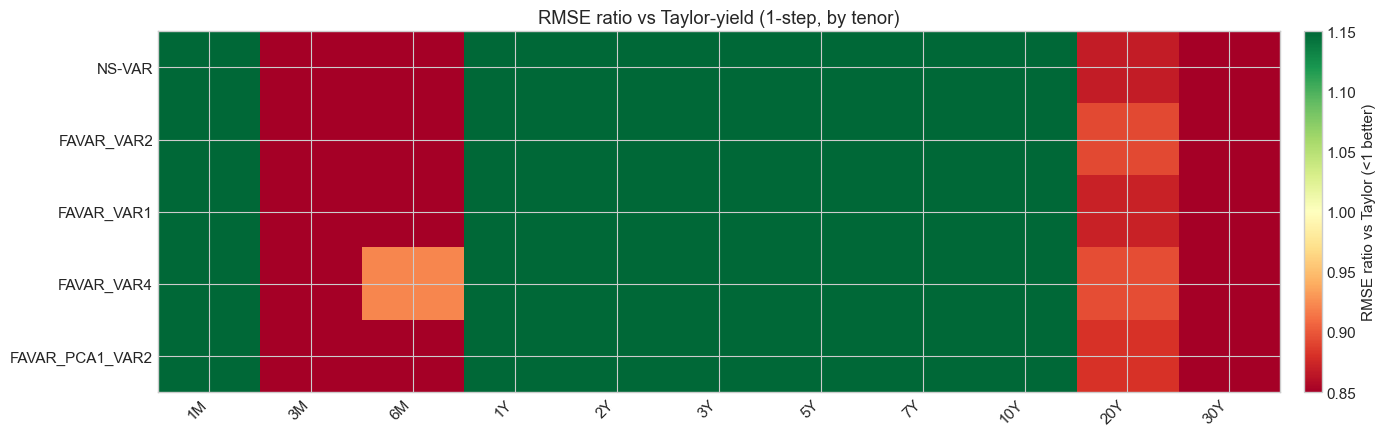

Figure saved: rmse_ratio_vs_taylor_heatmap.png


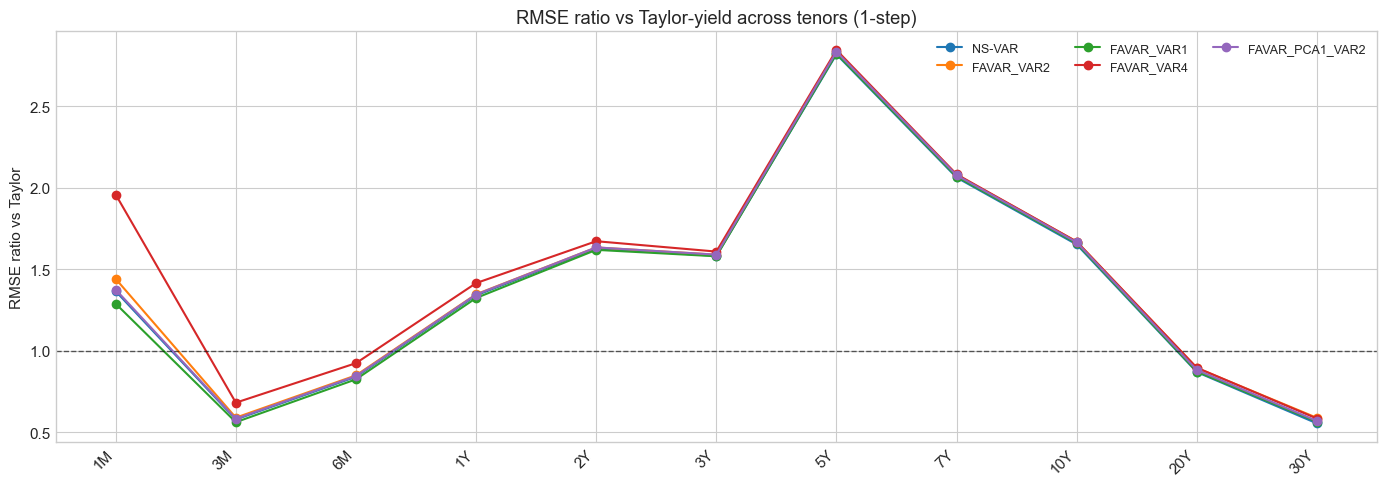

Figure saved: rmse_ratio_vs_taylor_by_tenor_lines.png


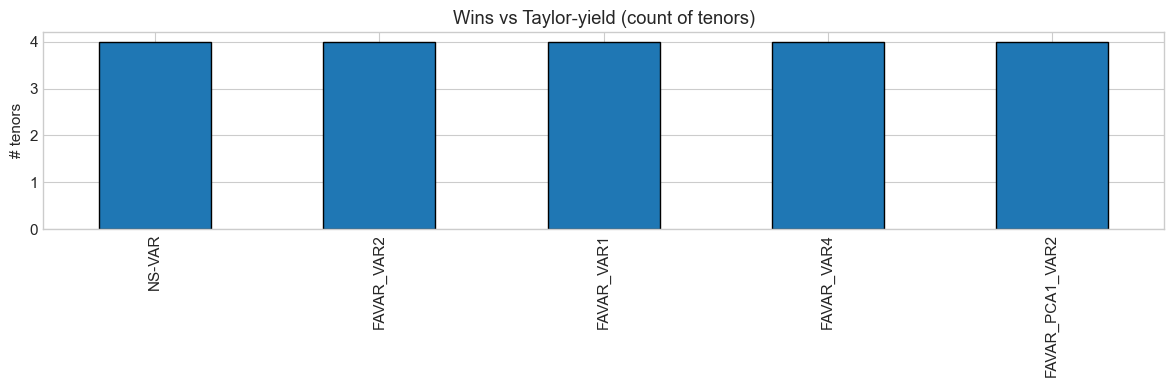

Figure saved: wins_vs_taylor.png


In [38]:
# --- Multi-model yield comparison across tenors (Taylor baseline) ---

# This section reuses the forecasts prepared earlier in the notebook via `yield_model_forecasts`.
# It focuses on: (i) RMSE tables, (ii) ratios vs Taylor, (iii) wins by tenor, and (iv) visuals.

def plot_wins_bar(series, title, filename):
    fig, ax = plt.subplots(figsize=(12, 4))
    series.plot(kind='bar', ax=ax, color='#1f77b4', edgecolor='black')
    ax.set_ylabel('# tenors')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')


def plot_ratio_heatmap(ratio_df, title, filename, vmin=0.85, vmax=1.15):
    """ratio_df: models x tenors (values are RMSE ratio vs Taylor)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    im = ax.imshow(ratio_df.values, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(ratio_df.index)))
    ax.set_yticklabels(list(ratio_df.index))
    ax.set_xticks(range(len(ratio_df.columns)))
    ax.set_xticklabels(list(ratio_df.columns), rotation=45, ha='right')
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label('RMSE ratio vs Taylor (<1 better)')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')


def plot_ratio_lines(ratio_df, title, filename):
    """ratio_df: tenors x models (non-Taylor models)."""
    x = np.arange(len(yield_cols))
    fig, ax = plt.subplots(figsize=(14, 5))
    for name in ratio_df.columns:
        ax.plot(x, ratio_df[name].values, marker='o', linewidth=1.5, label=name)
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.6, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(yield_cols, rotation=45, ha='right')
    ax.set_ylabel('RMSE ratio vs Taylor')
    ax.set_title(title)
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')


if 'yield_model_forecasts' not in globals():
    raise RuntimeError("Expected `yield_model_forecasts` to be defined earlier in the notebook.")

# RMSE table: tenors x models
model_names = list(yield_model_forecasts.keys())
rmse_multi = pd.DataFrame(index=yield_cols, columns=model_names, dtype=float)
for tenor in yield_cols:
    for name, fc in yield_model_forecasts.items():
        rmse_multi.loc[tenor, name] = compute_rmse(yields_actual_test[tenor], fc[tenor])

print("\nMulti-model RMSE by tenor (levels):")
display(rmse_multi.round(4))

# RMSE ratios vs Taylor (<1 means better than Taylor)
ratio_vs_taylor = rmse_multi.div(rmse_multi['Taylor'], axis=0)
ratio_vs_taylor = ratio_vs_taylor.drop(columns=['Taylor'])

print("\nRMSE ratio vs Taylor (<1 is improvement):")
display(ratio_vs_taylor.round(4))

# Identify the best FAVAR variant vs Taylor (only among FAVAR candidates)
favar_candidates = [c for c in ratio_vs_taylor.columns if c.startswith('FAVAR_')]
if len(favar_candidates) > 0:
    best_favar_overall = ratio_vs_taylor[favar_candidates].mean(axis=0).idxmin()
    best_favar_avg_ratio = float(ratio_vs_taylor[favar_candidates].mean(axis=0).min())
    yields_forecast_favar_best = yield_model_forecasts[best_favar_overall]
    print(f"\nBest FAVAR variant vs Taylor (lowest avg RMSE ratio): {best_favar_overall} (avg ratio = {best_favar_avg_ratio:.3f})")

# Wins vs Taylor (count tenors with RMSE < Taylor)
wins_vs_taylor = rmse_multi.drop(columns=['Taylor']).lt(rmse_multi['Taylor'], axis=0).sum(axis=0).sort_values(ascending=False)
print("\n# tenors where model beats Taylor-yield:")
display(wins_vs_taylor.to_frame('wins').T)

# Best model per tenor among all models in `rmse_multi`
best_model = rmse_multi.idxmin(axis=1)
print("\nBest (lowest RMSE) model by tenor:")
display(best_model.to_frame('best_model'))

# --- Visualization: heatmap + lines of RMSE ratio vs Taylor ---
heat = ratio_vs_taylor.T  # models x tenors
plot_ratio_heatmap(
    heat,
    title='RMSE ratio vs Taylor-yield (1-step, by tenor)',
    filename='rmse_ratio_vs_taylor_heatmap.png',
    vmin=0.85,
    vmax=1.15,
 )

plot_ratio_lines(
    ratio_vs_taylor,
    title='RMSE ratio vs Taylor-yield across tenors (1-step)',
    filename='rmse_ratio_vs_taylor_by_tenor_lines.png',
 )

# --- Visualization: wins vs Taylor ---
plot_wins_bar(wins_vs_taylor, 'Wins vs Taylor-yield (count of tenors)', 'wins_vs_taylor.png')

---
## 8. Visualization

Generate plots for thesis presentation.

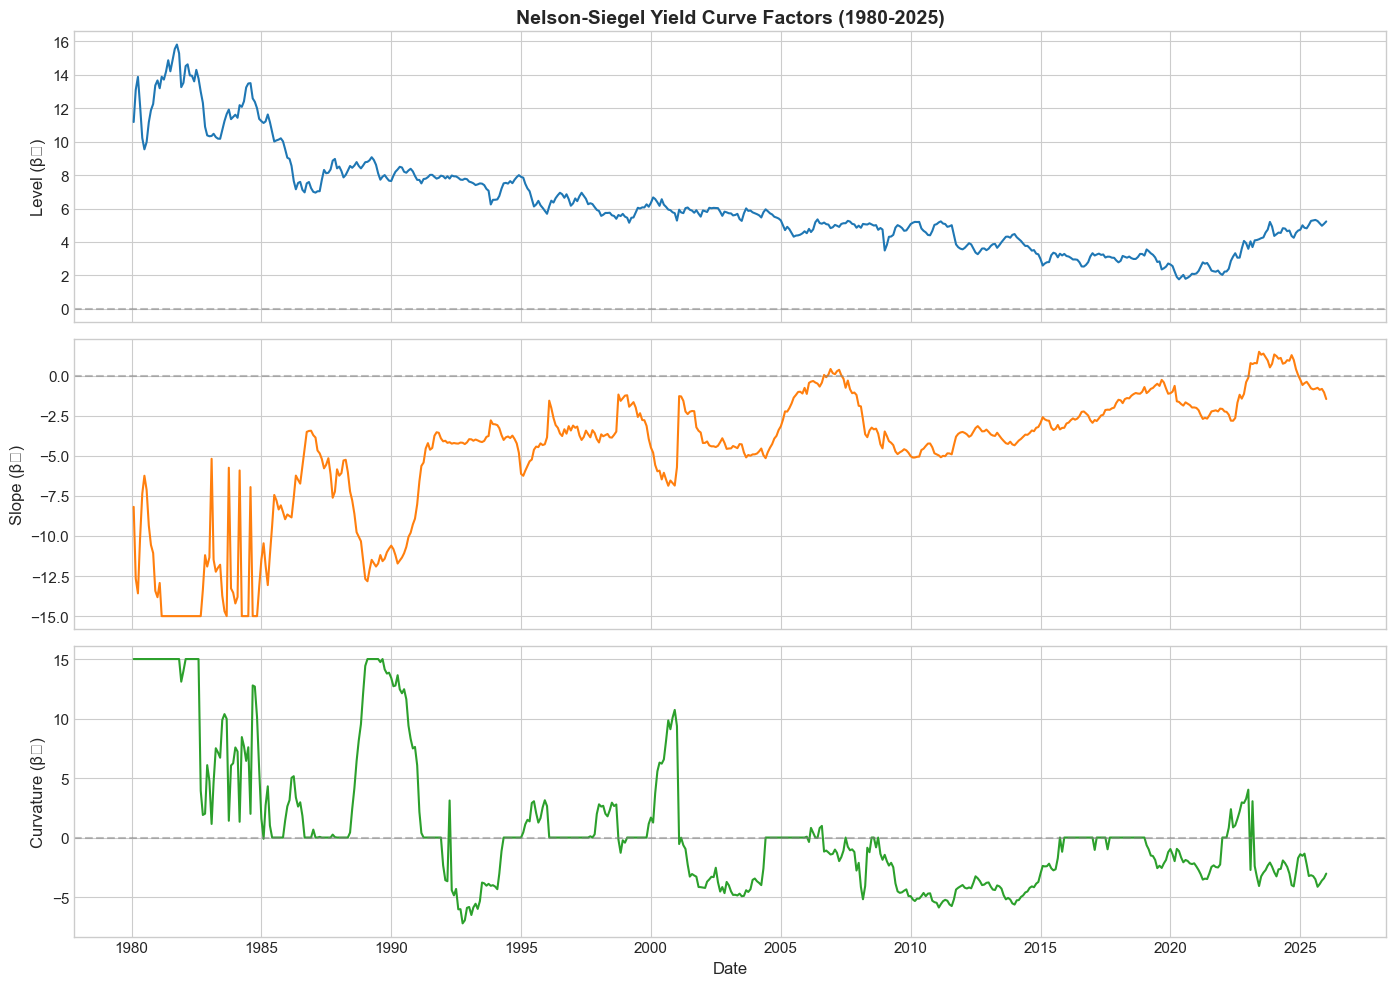

Figure saved: nelson_siegel_factors.png


In [28]:
# Plot 1: Nelson-Siegel Factors Over Time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

y0, y1 = ns_factors.index.min().year, ns_factors.index.max().year

# Level factor
axes[0].plot(ns_factors.index, ns_factors['level'], color='#1f77b4', linewidth=1.5)
axes[0].set_ylabel('Level (β₀)', fontsize=12)
axes[0].set_title(f'Nelson-Siegel Yield Curve Factors ({y0}-{y1})', fontsize=14, fontweight='bold')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Slope factor
axes[1].plot(ns_factors.index, ns_factors['slope'], color='#ff7f0e', linewidth=1.5)
axes[1].set_ylabel('Slope (β₁)', fontsize=12)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Curvature factor
axes[2].plot(ns_factors.index, ns_factors['curvature'], color='#2ca02c', linewidth=1.5)
axes[2].set_ylabel('Curvature (β₂)', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nelson_siegel_factors.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nelson_siegel_factors.png")

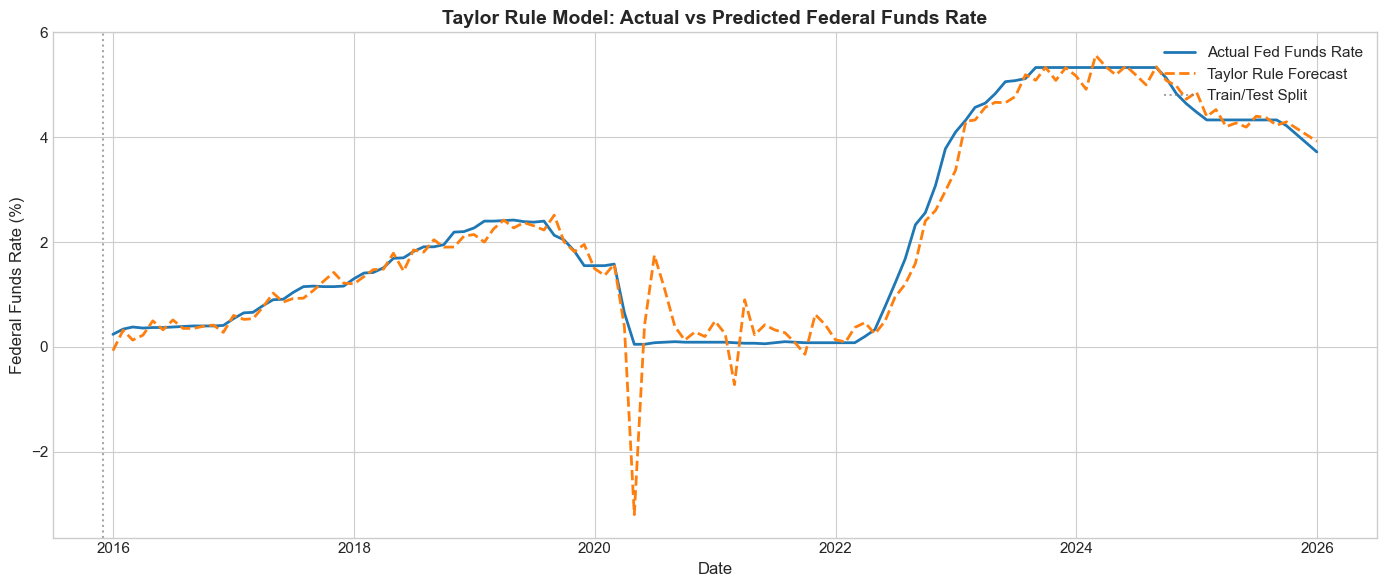

Figure saved: taylor_rule_forecast.png


In [29]:
# Plot 2: Taylor Rule - Actual vs Predicted Fed Funds Rate
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual values
ax.plot(taylor_actual.index, taylor_actual.values, 
        label='Actual Fed Funds Rate', color='#1f77b4', linewidth=2)

# Plot predictions
ax.plot(taylor_actual.index, taylor_forecasts.values, 
        label='Taylor Rule Forecast', color='#ff7f0e', linewidth=2, linestyle='--')

# Add vertical line for train/test split
ax.axvline(x=train_taylor.index[-1], color='gray', linestyle=':', 
           alpha=0.7, label='Train/Test Split')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Federal Funds Rate (%)', fontsize=12)
ax.set_title('Taylor Rule Model: Actual vs Predicted Federal Funds Rate', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('taylor_rule_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: taylor_rule_forecast.png")

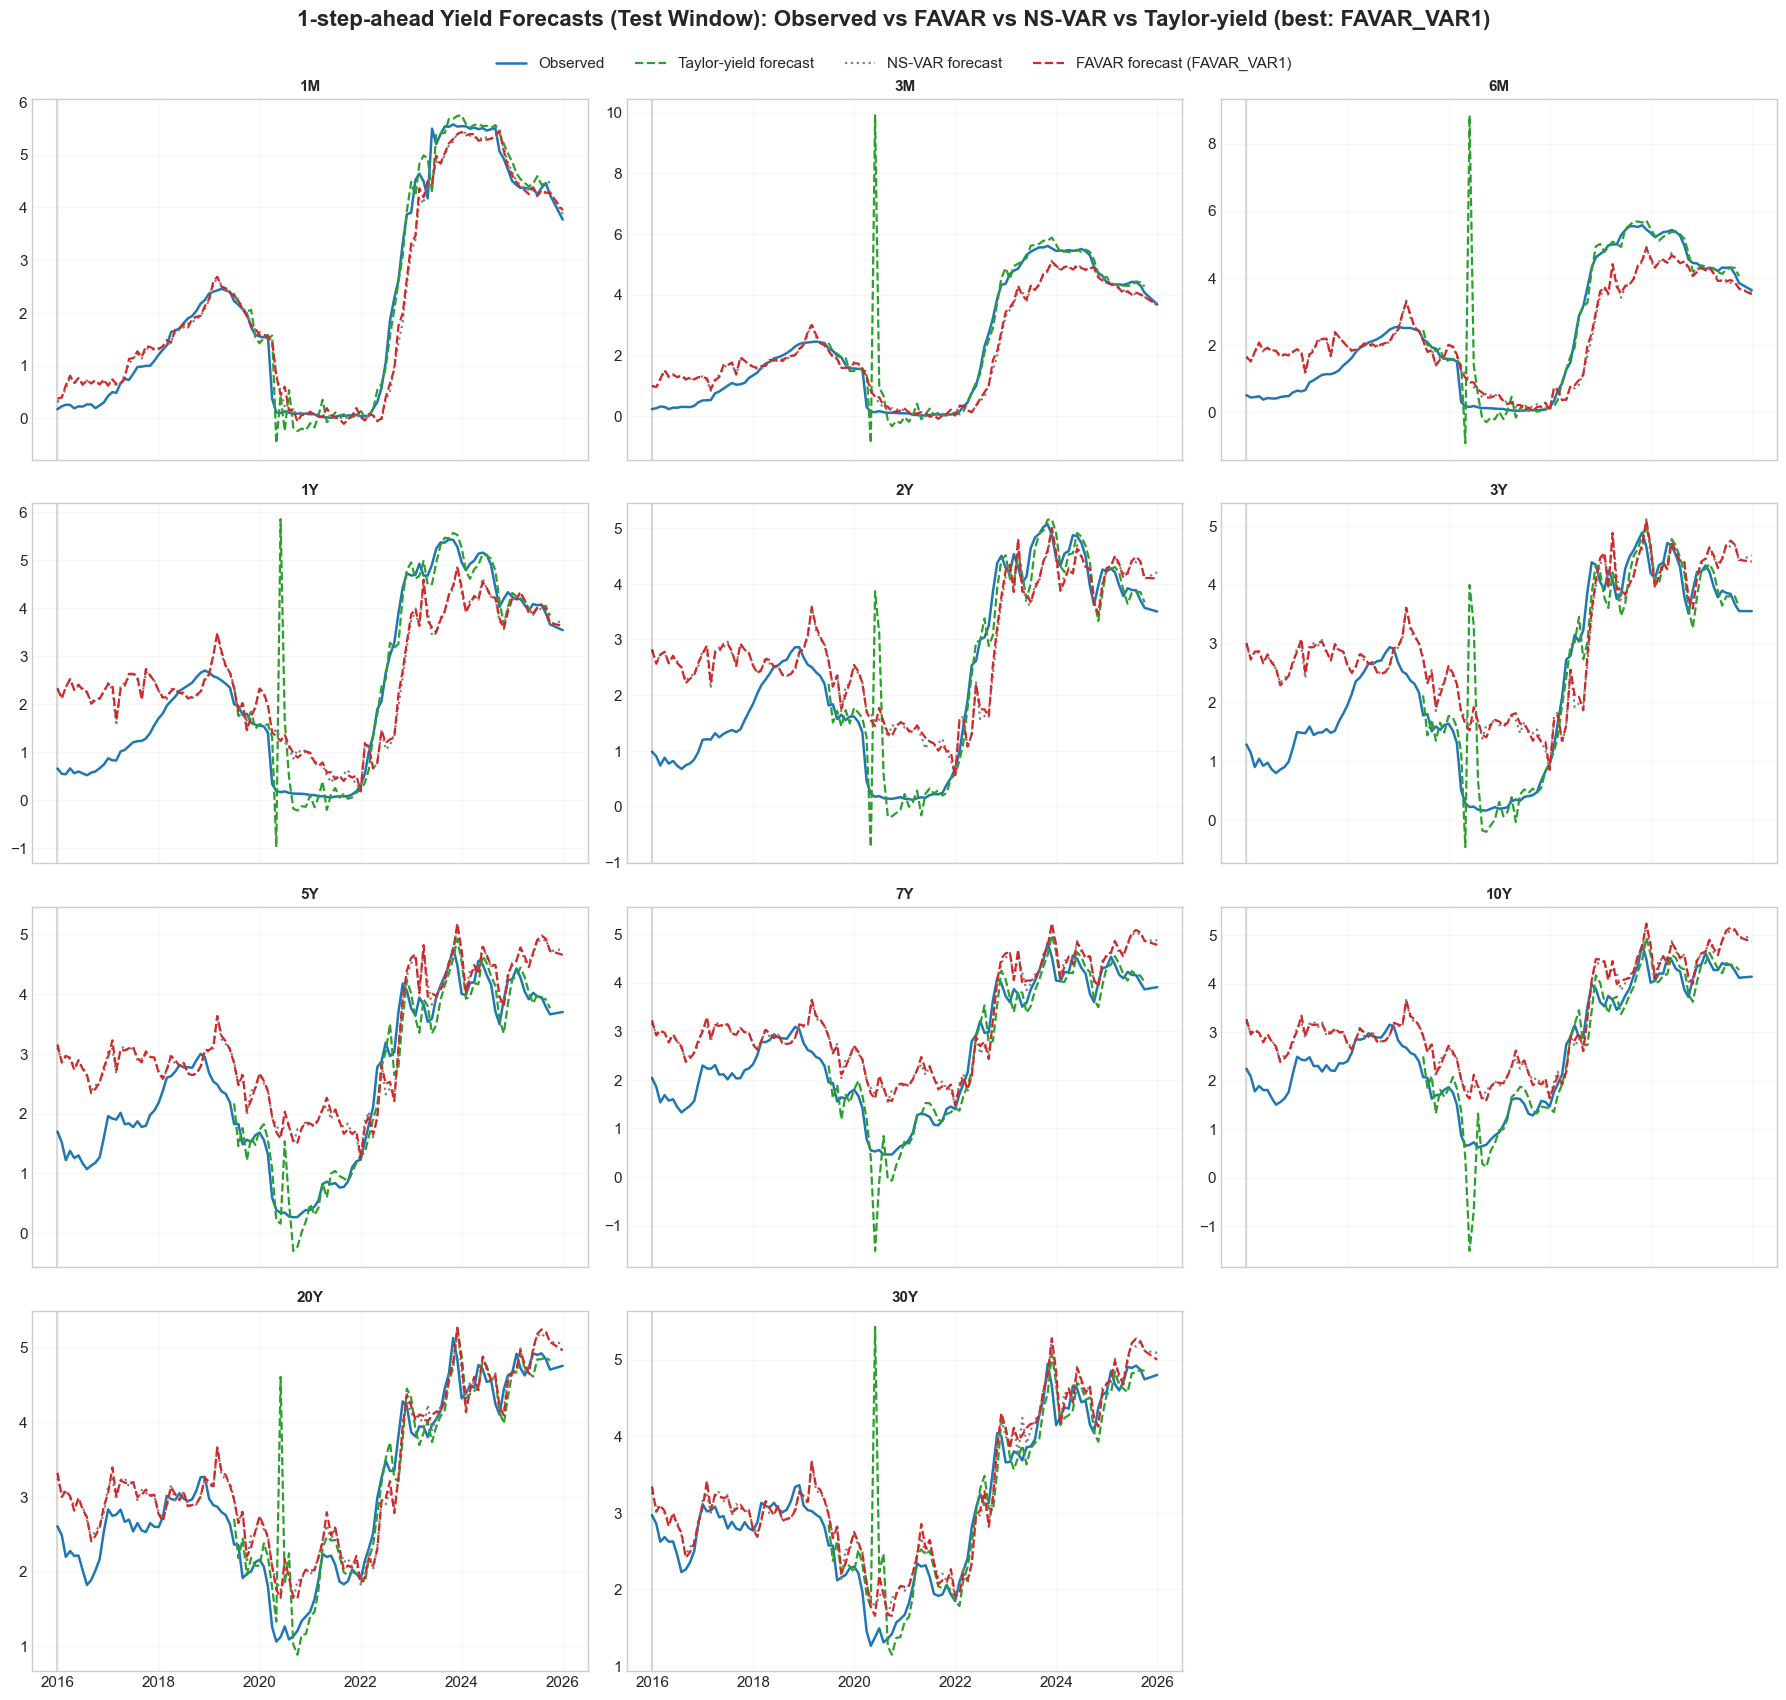

Figure saved: yields_favar_vs_taylor_all_tenors.png


In [39]:
# Plot 3: Observed vs Forecasted yields — best FAVAR vs NS-VAR vs Taylor (for each tenor in the test window)

import math

# Use the best FAVAR variant chosen in the multi-model block (fallback to baseline if needed)
best_favar_name = globals().get('best_favar_overall', None)
favar_fc = globals().get('yields_forecast_favar_best', yields_forecast_favar)
favar_label = f"FAVAR forecast ({best_favar_name})" if best_favar_name else "FAVAR forecast"

n = len(yield_cols)
ncols = 3
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(yield_cols):
    ax = axes[i]
    ax.plot(
        yields_actual_test.index,
        yields_actual_test[col].values,
        color='#1f77b4',
        linewidth=1.8,
        label='Observed' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        yields_forecast_taylor[col].reindex(yields_actual_test.index).values,
        color='#2ca02c',
        linewidth=1.6,
        linestyle='--',
        label='Taylor-yield forecast' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        yields_forecast_nsvar[col].reindex(yields_actual_test.index).values,
        color='gray',
        linewidth=1.6,
        linestyle=':',
        label='NS-VAR forecast' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        favar_fc[col].reindex(yields_actual_test.index).values,
        color='#d62728',
        linewidth=1.6,
        linestyle='--',
        label=favar_label if i == 0 else None,
    )
    ax.axvline(x=split_date, color='black', linestyle='-', alpha=0.15)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.15)

# Turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

title_suffix = f" (best: {best_favar_name})" if best_favar_name else ""
fig.suptitle(
    f"1-step-ahead Yield Forecasts (Test Window): Observed vs FAVAR vs NS-VAR vs Taylor-yield{title_suffix}",
    fontsize=16,
    fontweight='bold',
    y=1.01,
 )
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.99), frameon=False)

plt.tight_layout()
plt.savefig('yields_favar_vs_taylor_all_tenors.png', dpi=300, bbox_inches='tight')
plt.show()

print('Figure saved: yields_favar_vs_taylor_all_tenors.png')

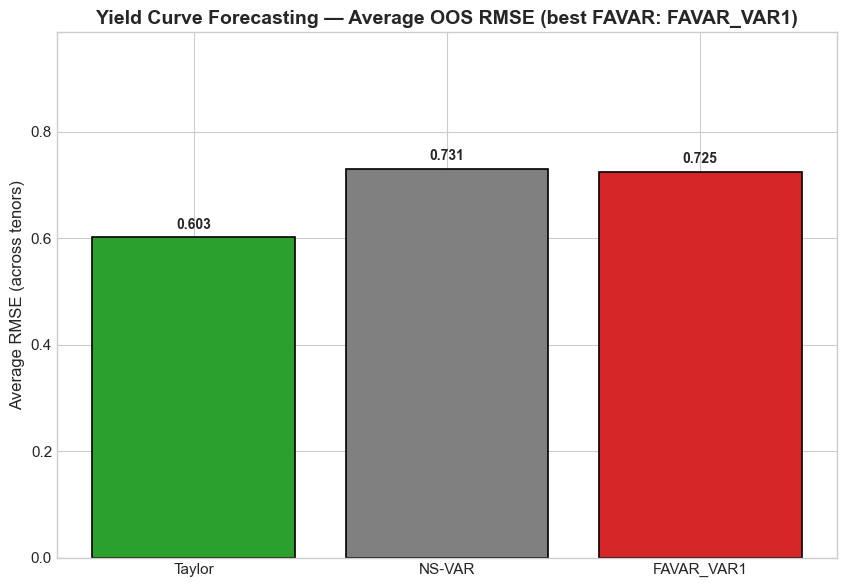

Figure saved: avg_rmse_favar_vs_taylor.png


In [40]:
# Plot 4: Average RMSE Comparison — Taylor vs NS-VAR vs best FAVAR (Yield Curve)
fig, ax = plt.subplots(figsize=(8.6, 6))

best_favar_name = globals().get('best_favar_overall', None)
rmse_values = None
models = None

if 'rmse_multi' in globals() and best_favar_name is not None and best_favar_name in rmse_multi.columns:
    models = ['Taylor', 'NS-VAR', best_favar_name]
    rmse_values = [float(rmse_multi[m].mean()) for m in models]
elif 'yield_rmse_ft_df' in globals() and best_favar_name is not None and best_favar_name in yield_rmse_ft_df.columns and 'NS-VAR' in yield_rmse_ft_df.columns:
    models = ['Taylor', 'NS-VAR', best_favar_name]
    rmse_values = [float(yield_rmse_ft_df[m].mean()) for m in models]
else:
    # Fallback to baseline headline comparison
    models = ['Taylor', 'NS-VAR', 'FAVAR_VAR2']
    rmse_values = [
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_taylor[t]) for t in yield_cols]).mean()),
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_nsvar[t]) for t in yield_cols]).mean()),
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_favar[t]) for t in yield_cols]).mean()),
    ]

colors = ['#2ca02c', 'gray', '#d62728']
bars = ax.bar(models, rmse_values, color=colors, edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )

ax.set_ylabel('Average RMSE (across tenors)', fontsize=12)
title_suffix = f" (best FAVAR: {best_favar_name})" if best_favar_name else ""
ax.set_title(f'Yield Curve Forecasting — Average OOS RMSE{title_suffix}', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(rmse_values) * 1.35)

plt.tight_layout()
plt.savefig('avg_rmse_favar_vs_taylor.png', dpi=300, bbox_inches='tight')
plt.show()

print('Figure saved: avg_rmse_favar_vs_taylor.png')

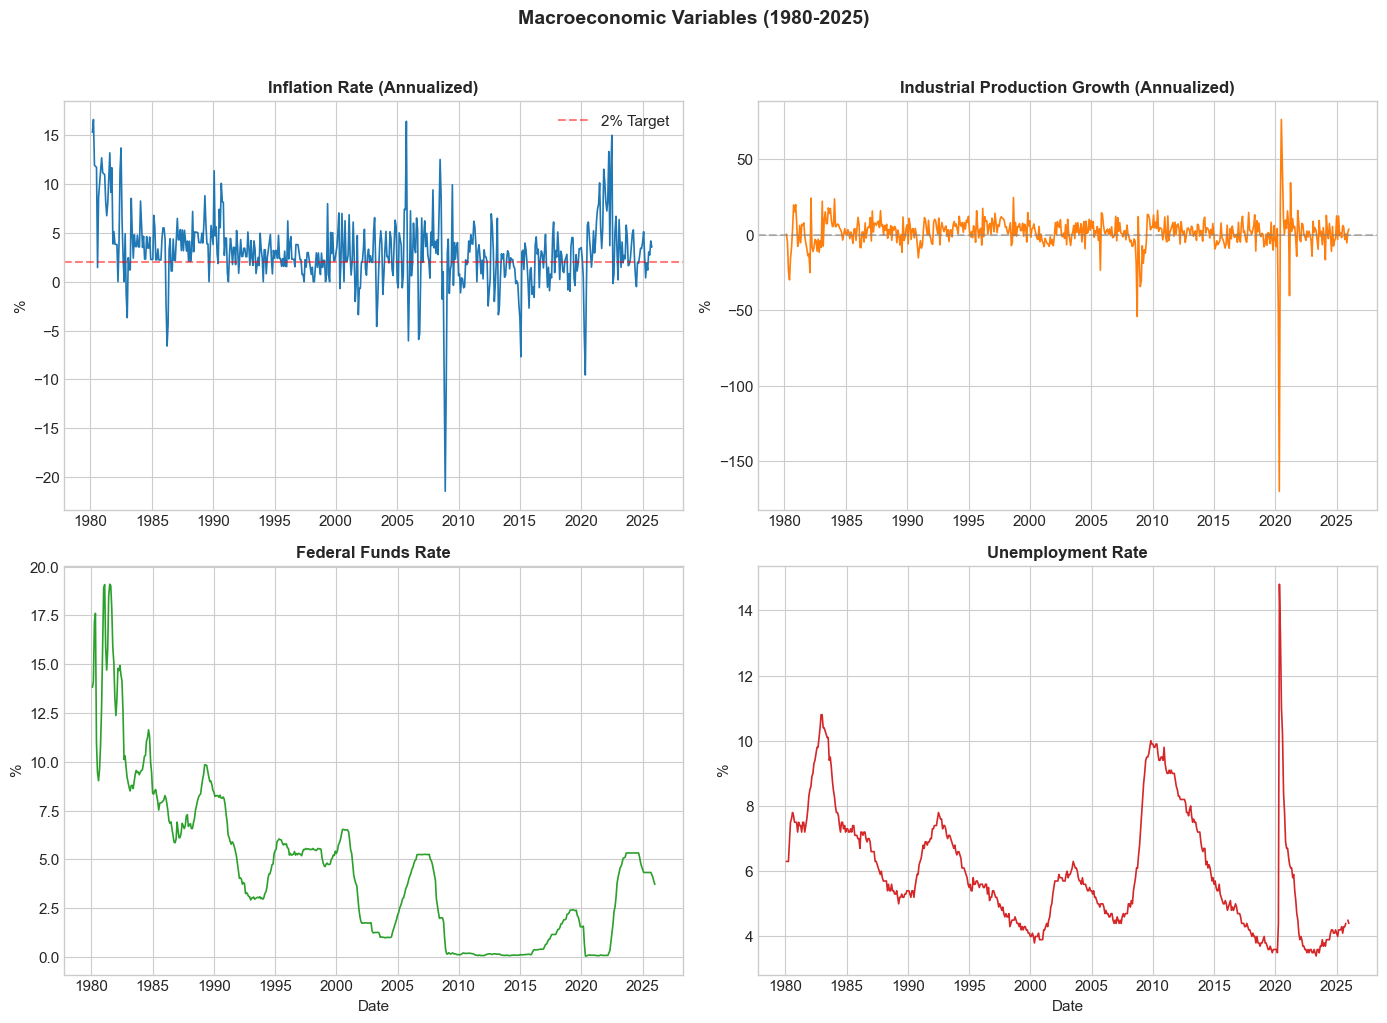

Figure saved: macro_variables.png


In [32]:
# Plot 5: Macro Variables Over Time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

y0, y1 = macro_aligned.index.min().year, macro_aligned.index.max().year

# Inflation
axes[0, 0].plot(macro_aligned.index, macro_aligned['inflation'], color='#1f77b4', linewidth=1.2)
axes[0, 0].set_title('Inflation Rate (Annualized)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('%')
axes[0, 0].axhline(y=2, color='red', linestyle='--', alpha=0.5, label='2% Target')
axes[0, 0].legend()

# Output Growth
axes[0, 1].plot(macro_aligned.index, macro_aligned['output'], color='#ff7f0e', linewidth=1.2)
axes[0, 1].set_title('Industrial Production Growth (Annualized)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('%')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Fed Funds Rate
axes[1, 0].plot(macro_aligned.index, macro_aligned['fedfunds'], color='#2ca02c', linewidth=1.2)
axes[1, 0].set_title('Federal Funds Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('%')
axes[1, 0].set_xlabel('Date')

# Unemployment Rate
axes[1, 1].plot(macro_aligned.index, macro_aligned['unrate'], color='#d62728', linewidth=1.2)
axes[1, 1].set_title('Unemployment Rate', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('%')
axes[1, 1].set_xlabel('Date')

plt.suptitle(f'Macroeconomic Variables ({y0}-{y1})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('macro_variables.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: macro_variables.png")

---
## Summary

**Goal:** compare yield-curve forecasting performance tenor-by-tenor using three baselines: **Taylor-yield**, **NS-VAR**, and **FAVAR** (plus additional FAVAR variants).

### What we built

- **Yield curve representation:** Nelson–Siegel factors (level/slope/curvature), estimated cross-sectionally each month; yields are reconstructed using a random-walk forecast for $\lambda$ to keep the mapping consistent.
- **Macro factors:** PCA factors extracted from a coverage-filtered macro panel to form the latent macro block used in FAVARs.
- **Forecasting protocol:** expanding-window pseudo out-of-sample evaluation on the last `TEST_YEARS` years; 1-step-ahead forecasts.
- **Models compared (by tenor):**
  - Taylor-yield (macro Taylor information set, estimated separately per tenor)
  - NS-VAR baseline (VAR on NS factors only)
  - Best FAVAR (selected by average RMSE ratio vs Taylor) + additional FAVAR variants

### What to look at

- **RMSE-by-tenor table** (core models): shows RMSE for Taylor, NS-VAR, and the selected best FAVAR **for each tenor**, plus which model is best at that tenor.
- **RMSE ratio heatmap vs Taylor** (`rmse_ratio_vs_taylor_heatmap.png`): each cell is RMSE(model)/RMSE(Taylor). Values < 1 beat Taylor-yield.
- **RMSE ratio curves vs Taylor** (`rmse_ratio_vs_taylor_by_tenor_lines.png`): where each model is strong/weak across tenors.
- **Win-count bars vs Taylor** (`wins_vs_taylor.png`): how often each alternative beats Taylor across tenors.
- **Observed vs forecasts (test window)** (`yields_favar_vs_taylor_all_tenors.png`): overlays observed yields with Taylor, NS-VAR, and the selected “best” FAVAR spec, for each tenor.
- **Average RMSE bar chart** (`avg_rmse_favar_vs_taylor.png`): headline average OOS RMSE across tenors for Taylor vs NS-VAR vs best FAVAR.

### Key takeaway (for this sample, 1-step ahead)

Use the RMSE-by-tenor table and the “tenor wins” counts to see where each approach dominates (short end vs mid-curve vs long end). In this setup, the “best” model can differ materially across tenors, so the per-tenor view is more informative than a single average metric.

In [41]:
# Final summary statistics
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"Data Period (aligned): {common_index[0].strftime('%Y-%m')} to {common_index[-1].strftime('%Y-%m')}")
print(f"Total Observations (monthly): {len(common_index)}")
print(f"Test Window (yields): {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')}")
print(f"Train/Test Split Date: {split_date.strftime('%Y-%m')}")

print(f"\nVAR Lag Order: {VAR_LAGS}")
print(f"PCA Components: {pca_model.n_components_} (Explained Variance: {sum(variance_ratios)*100:.1f}%)")
print("NS lambda handling in yield reconstruction: random-walk (lambda_t = lambda_(t-1))")
print(f"Median lambda in sample: {ns_factors['lambda'].median():.4f}")

print("\n" + "-" * 70)
print("YIELD CURVE OUT-OF-SAMPLE PERFORMANCE (Taylor vs NS-VAR vs best FAVAR)")
print("-" * 70)

favar_name = best_favar_overall
core_cols = ['Taylor', 'NS-VAR', favar_name]

avg_rmse = yield_rmse_ft_df[core_cols].mean(axis=0).round(4)
avg_mae = yield_mae_ft_df[core_cols].mean(axis=0).round(4)

print(f"Best FAVAR spec (by avg RMSE ratio vs Taylor): {favar_name}")
print("\nAverage RMSE across tenors:")
print(avg_rmse.to_string())
print("\nAverage MAE across tenors:")
print(avg_mae.to_string())

# Pairwise diagnostics vs Taylor
for name in ['NS-VAR', favar_name]:
    avg_rel = float((yield_rmse_ft_df[name] / yield_rmse_ft_df['Taylor']).mean())
    wins_rmse = int((yield_rmse_ft_df[name] < yield_rmse_ft_df['Taylor']).sum())
    wins_mae = int((yield_mae_ft_df[name] < yield_mae_ft_df['Taylor']).sum())
    avg_wr = float(yield_winrate_vs_taylor[name].mean())
    label = name
    if name == favar_name:
        label = f"Best FAVAR ({favar_name})"
    print(f"\nDiagnostics vs Taylor (yields) — {label}:")
    print(f"  Avg RMSE ratio (model/Taylor): {avg_rel:.4f}  (<1 favors model)")
    print(f"  # tenors model beats Taylor (RMSE): {wins_rmse} / {len(yield_cols)}")
    print(f"  # tenors model beats Taylor (MAE):  {wins_mae} / {len(yield_cols)}")
    print(f"  Avg win-rate P(|e_model| < |e_Taylor|): {avg_wr:.3f}")

# Best model counts (lowest RMSE among the 3 core models)
best_model_by_tenor = yield_rmse_ft_df[core_cols].idxmin(axis=1)
counts = best_model_by_tenor.value_counts()
print("\nBest model by tenor (lowest RMSE among Taylor / NS-VAR / best FAVAR):")
print(counts.to_string())

print("\n" + "-" * 70)
print("FED FUNDS (TAYLOR RULE) OUT-OF-SAMPLE")
print("-" * 70)
print(f"Taylor RMSE: {taylor_rmse:.4f}")

print("=" * 70)


FINAL SUMMARY
Data Period (aligned): 1980-01 to 2025-12
Total Observations (monthly): 552
Test Window (yields): 2015-12 to 2025-12
Train/Test Split Date: 2015-12

VAR Lag Order: 2
PCA Components: 3 (Explained Variance: 71.4%)
NS lambda handling in yield reconstruction: random-walk (lambda_t = lambda_(t-1))
Median lambda in sample: 1.2172

----------------------------------------------------------------------
YIELD CURVE OUT-OF-SAMPLE PERFORMANCE (Taylor vs NS-VAR vs best FAVAR)
----------------------------------------------------------------------
Best FAVAR spec (by avg RMSE ratio vs Taylor): FAVAR_VAR1

Average RMSE across tenors:
Taylor        0.6027
NS-VAR        0.7310
FAVAR_VAR1    0.7252

Average MAE across tenors:
Taylor        0.2738
NS-VAR        0.5916
FAVAR_VAR1    0.5914

Diagnostics vs Taylor (yields) — NS-VAR:
  Avg RMSE ratio (model/Taylor): 1.3888  (<1 favors model)
  # tenors model beats Taylor (RMSE): 4 / 11
  # tenors model beats Taylor (MAE):  1 / 11
  Avg win-rat